# Lab 2 - Preparação dos Dados
## Importação e carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_treino = pd.read_csv('../material/lab2_cmc13_dados_treinamento.csv')
df_teste = pd.read_csv('../material/lab2_cmc13_dados_teste.csv')

## Diagnóstico




In [3]:
print(f'Treino: {df_treino.shape[0]} linhas, {df_treino.shape[1]} colunas')
print(f'Teste:  {df_teste.shape[0]} linhas, {df_teste.shape[1]} colunas')
df_treino.head()

Treino: 440833 linhas, 12 colunas
Teste:  64374 linhas, 12 colunas


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [4]:
# Linhas completamente vazias (todos os valores NaN)
linhas_vazias = df_treino[df_treino.isnull().all(axis=1)]
print(f"Linhas completamente vazias: {len(linhas_vazias)}")
print(f"Índices: {linhas_vazias.index.tolist()}")
linhas_vazias
# Remover linhas completamente vazias
df_treino = df_treino.dropna(how='all').reset_index(drop=True)
print(f"Treino após remoção: {df_treino.shape[0]} linhas")

Linhas completamente vazias: 1
Índices: [199295]
Treino após remoção: 440832 linhas


In [5]:
df_treino.info()
print("------------")
df_teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-

## Ajustes Iniciais

Transformações aplicadas antes da análise exploratória para que os gráficos reflitam as features que serão efetivamente usadas nos modelos:

1. **Remover `CustomerID`** — identificador, sem valor preditivo
2. **Converter float → int** (treino) — artefato da linha NaN removida
3. **Label Encoding em `Gender`** — binária (Male=0, Female=1)
4. **Ordinal Encoding em `Contract Length`** — ordem natural de duração (Monthly=1, Quarterly=3, Annual=12)
5. **One-Hot Encoding em `Subscription Type`** — sem ordem natural entre categorias (drop_first=True)

In [6]:
# 1. Remover CustomerID
df_treino = df_treino.drop(columns=['CustomerID'])
df_teste = df_teste.drop(columns=['CustomerID'])

# 2. Converter float → int (treino)
cols_float = df_treino.select_dtypes(include=[float]).columns
df_treino[cols_float] = df_treino[cols_float].astype(int)

# 3. Label Encoding — Gender (Male=0, Female=1)
df_treino['Gender'] = df_treino['Gender'].map({'Male': 0, 'Female': 1})
df_teste['Gender'] = df_teste['Gender'].map({'Male': 0, 'Female': 1})

# 4. Ordinal Encoding — Contract Length (Monthly=1, Quarterly=3, Annual=12)
df_treino['Contract Length'] = df_treino['Contract Length'].map({'Monthly': 1, 'Quarterly': 3, 'Annual': 12})
df_teste['Contract Length'] = df_teste['Contract Length'].map({'Monthly': 1, 'Quarterly': 3, 'Annual': 12})

# 5. One-Hot Encoding — Subscription Type (drop_first=True)
df_treino = pd.get_dummies(df_treino, columns=['Subscription Type'], drop_first=True, dtype=int)
df_teste = pd.get_dummies(df_teste, columns=['Subscription Type'], drop_first=True, dtype=int)

# Dicionário de labels para legibilidade nos gráficos
labels = {
    'Gender': {0: 'Male', 1: 'Female'},
    'Contract Length': {1: 'Monthly', 3: 'Quarterly', 12: 'Annual'}
}

print(f'Treino: {df_treino.shape} | Teste: {df_teste.shape}')
df_treino.head()

Treino: (440832, 12) | Teste: (64374, 12)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Contract Length,Total Spend,Last Interaction,Churn,Subscription Type_Premium,Subscription Type_Standard
0,30,1,39,14,5,18,12,932,17,1,0,1
1,65,1,49,1,10,8,1,557,6,1,0,0
2,55,1,14,4,6,18,3,185,3,1,0,0
3,58,0,38,21,7,7,1,396,29,1,0,1
4,23,0,32,20,5,8,1,617,20,1,0,0


## Análise Exploratória

In [7]:
# Comparação Treino vs Teste — todas as features (agora numéricas)
print("=" * 80)
print("COMPARAÇÃO TREINO vs TESTE - LADO A LADO")
print("=" * 80)

for col in df_treino.columns:
    print(f"\n{'─' * 80}")
    label_extra = ''
    if col in labels:
        label_extra = f"  ({', '.join(f'{k}={v}' for k, v in labels[col].items())})"
    print(f"  {col}{label_extra}")
    print(f"{'─' * 80}")
    
    stats = pd.DataFrame({
        'Treino': [
            df_treino[col].count(),
            df_treino[col].isnull().sum(),
            df_treino[col].nunique(),
            df_treino[col].mean(),
            df_treino[col].std(),
            df_treino[col].min(),
            df_treino[col].quantile(0.25),
            df_treino[col].median(),
            df_treino[col].quantile(0.75),
            df_treino[col].max(),
            df_treino[col].skew(),
            df_treino[col].kurtosis()
        ],
        'Teste': [
            df_teste[col].count(),
            df_teste[col].isnull().sum(),
            df_teste[col].nunique(),
            df_teste[col].mean(),
            df_teste[col].std(),
            df_teste[col].min(),
            df_teste[col].quantile(0.25),
            df_teste[col].median(),
            df_teste[col].quantile(0.75),
            df_teste[col].max(),
            df_teste[col].skew(),
            df_teste[col].kurtosis()
        ]
    }, index=['count', 'missing', 'únicos', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis'])
    print(stats.to_string())

COMPARAÇÃO TREINO vs TESTE - LADO A LADO

────────────────────────────────────────────────────────────────────────────────
  Age
────────────────────────────────────────────────────────────────────────────────


                 Treino         Teste
count     440832.000000  64374.000000
missing        0.000000      0.000000
únicos        48.000000     48.000000
mean          39.373153     41.970982
std           12.442369     13.924911
min           18.000000     18.000000
25%           29.000000     30.000000
50%           39.000000     42.000000
75%           48.000000     54.000000
max           65.000000     65.000000
skew           0.162016     -0.040894
kurtosis      -0.864853     -1.215321

────────────────────────────────────────────────────────────────────────────────
  Gender  (0=Male, 1=Female)
────────────────────────────────────────────────────────────────────────────────
                 Treino         Teste
count     440832.000000  64374.000000
missing        0.000000      0.000000
únicos         2.000000      2.000000
mean           0.432319      0.533647
std            0.495399      0.498870
min            0.000000      0.000000
25%            0.000000      0.000000
50%       

                 Treino         Teste
count     440832.000000  64374.000000
missing        0.000000      0.000000
únicos        31.000000     31.000000
mean          12.965722     17.133952
std            8.258063      8.852211
min            0.000000      0.000000
25%            6.000000     10.000000
50%           12.000000     19.000000
75%           19.000000     25.000000
max           30.000000     30.000000
skew           0.267407     -0.350714
kurtosis      -0.895678     -1.063939

────────────────────────────────────────────────────────────────────────────────
  Contract Length  (1=Monthly, 3=Quarterly, 12=Annual)
────────────────────────────────────────────────────────────────────────────────
                 Treino         Teste
count     440832.000000  64374.000000
missing        0.000000      0.000000
únicos         3.000000      3.000000
mean           6.222484      5.305745
std            4.792180      4.795685
min            1.000000      1.000000
25%            3.00000

                 Treino         Teste
count     440832.000000  64374.000000
missing        0.000000      0.000000
únicos       901.000000    901.000000
mean         631.344771    541.023379
std          240.722712    260.874809
min          100.000000    100.000000
25%          480.000000    313.000000
50%          661.000000    534.000000
75%          830.000000    768.000000
max         1000.000000   1000.000000
skew          -0.456825      0.047746
kurtosis      -0.751476     -1.212900

────────────────────────────────────────────────────────────────────────────────
  Last Interaction
────────────────────────────────────────────────────────────────────────────────
                 Treino         Teste
count     440832.000000  64374.000000
missing        0.000000      0.000000
únicos        30.000000     30.000000
mean          14.480868     15.498850
std            8.596208      8.638436
min            1.000000      1.000000
25%            7.000000      8.000000
50%           14.000

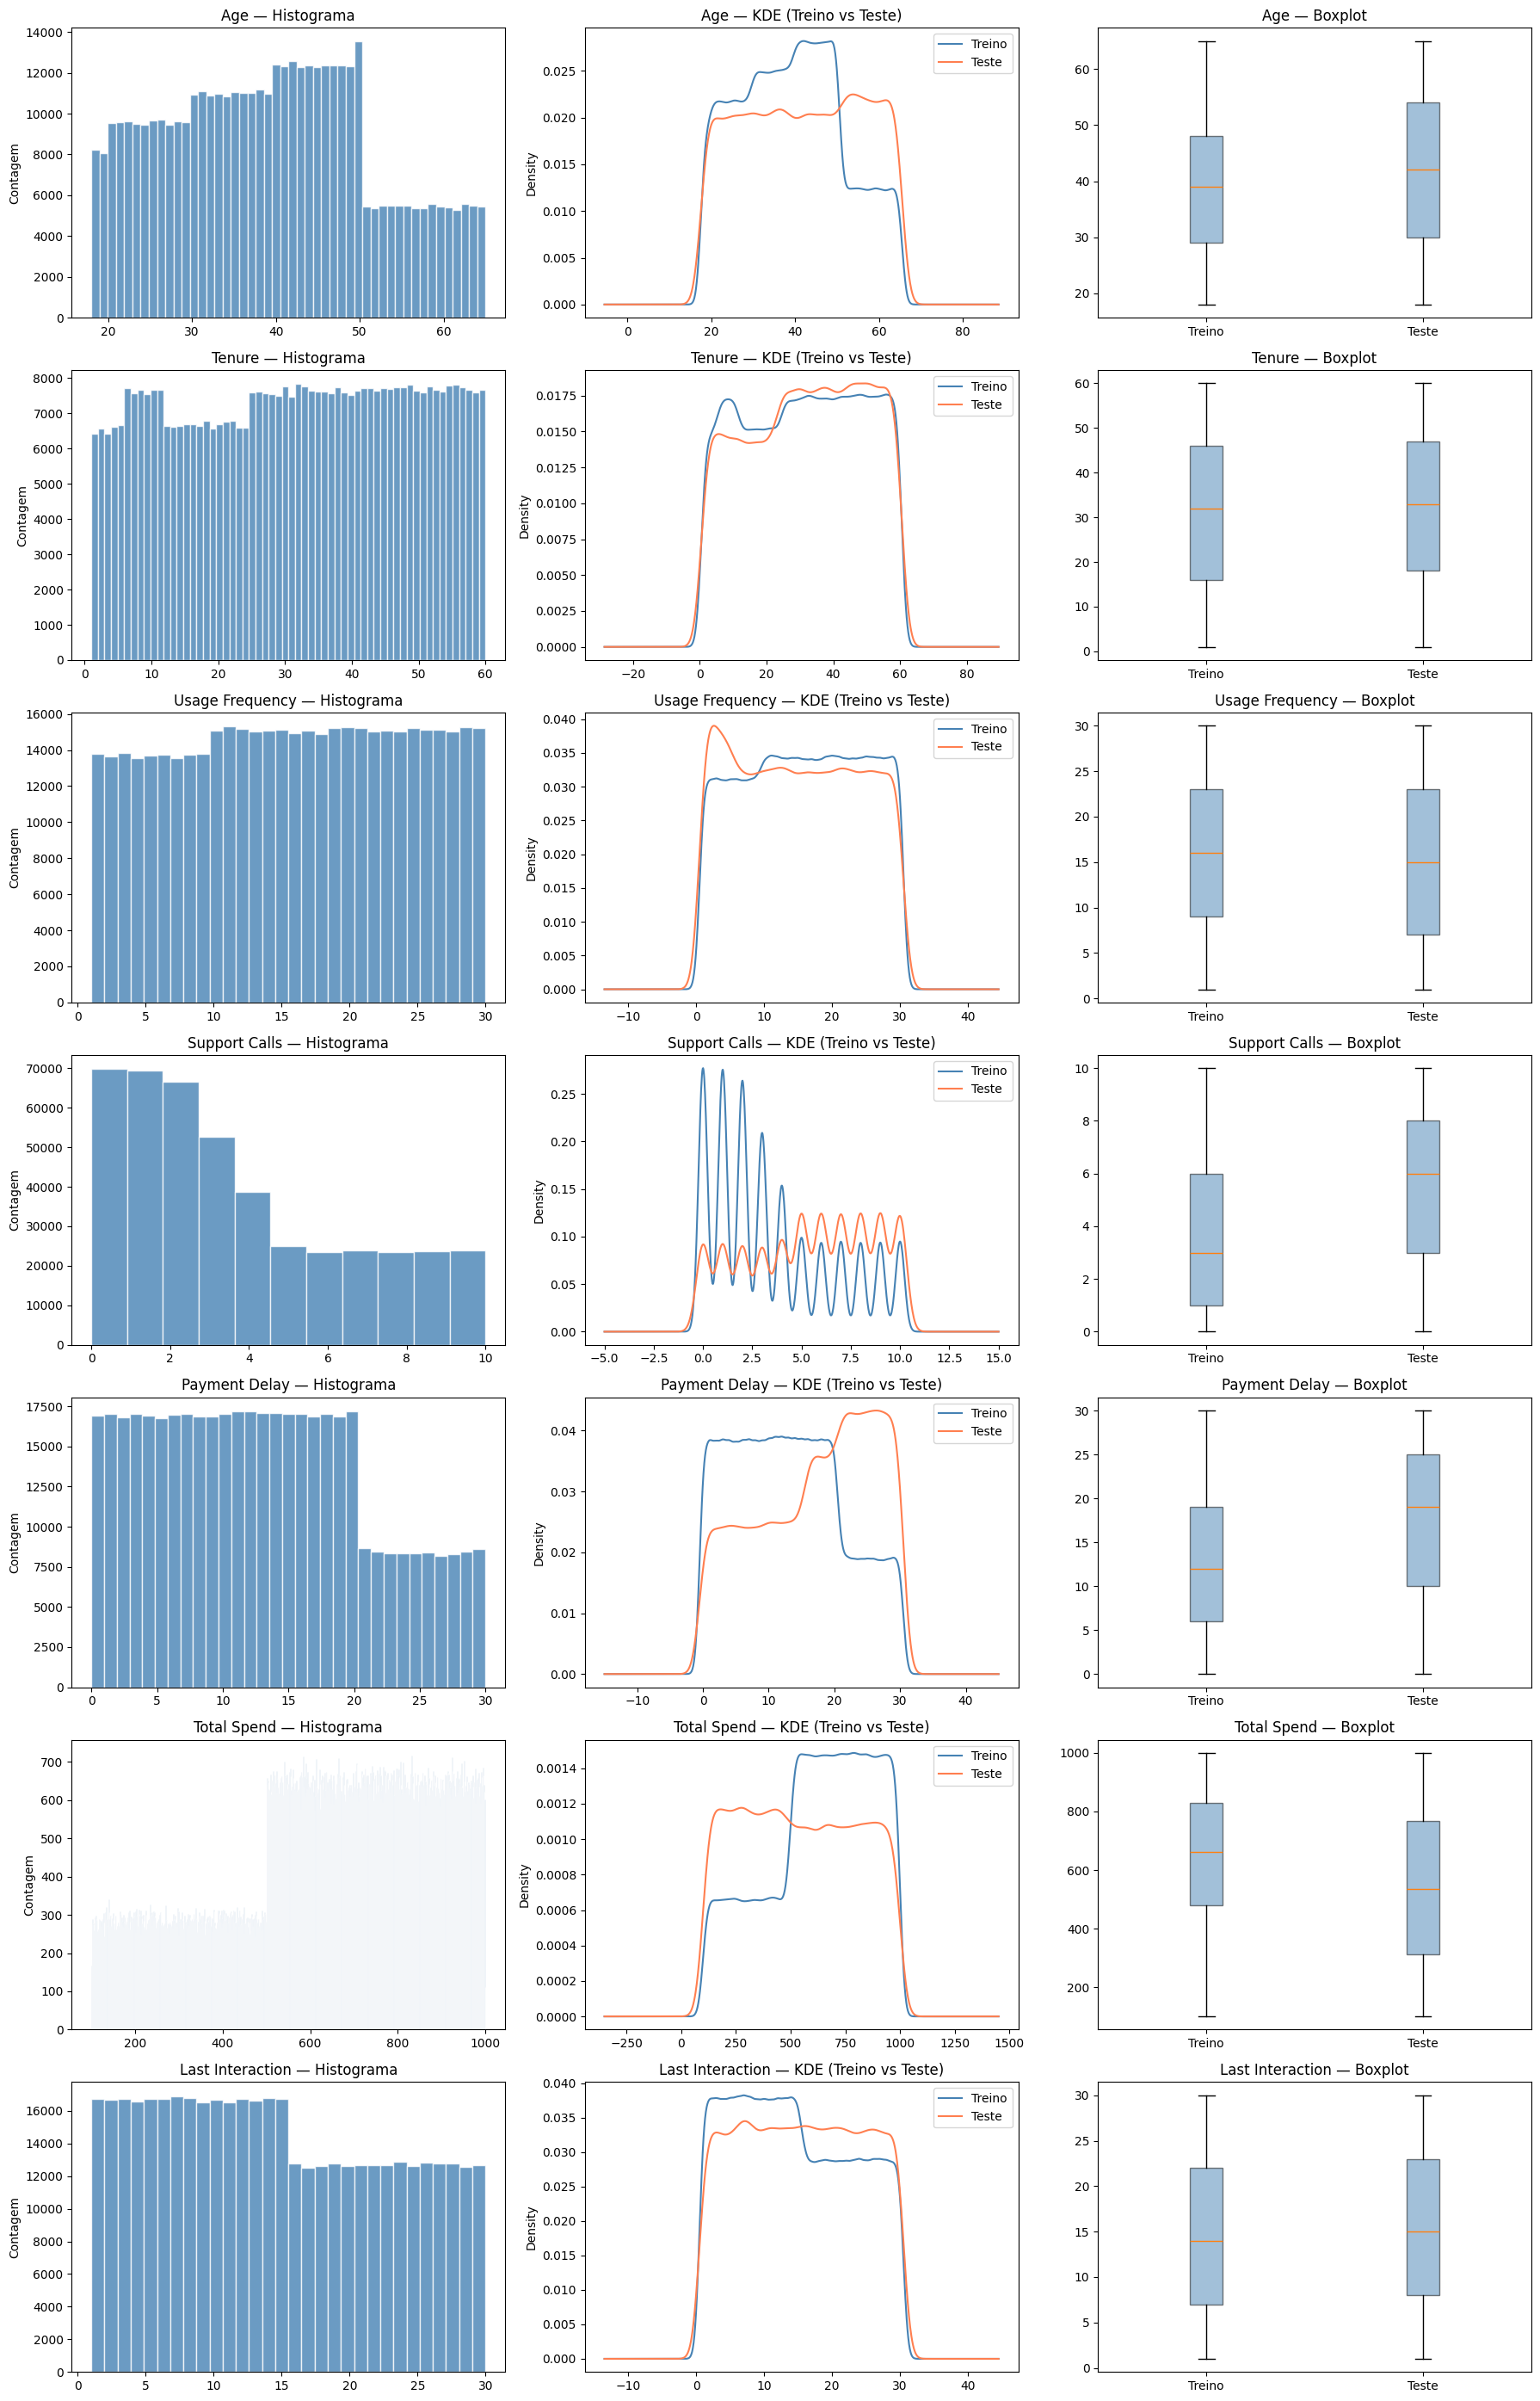

In [8]:
# Features contínuas: Histograma + KDE + Boxplot
cols_continuas = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
                  'Payment Delay', 'Total Spend', 'Last Interaction']

fig, axes = plt.subplots(len(cols_continuas), 3, figsize=(18, 4 * len(cols_continuas)))

for i, col in enumerate(cols_continuas):
    n_bins = df_treino[col].nunique()
    
    # Histograma
    axes[i, 0].hist(df_treino[col], bins=n_bins, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{col} — Histograma')
    axes[i, 0].set_ylabel('Contagem')
    
    # KDE
    df_treino[col].plot.kde(ax=axes[i, 1], color='steelblue', label='Treino')
    df_teste[col].plot.kde(ax=axes[i, 1], color='coral', label='Teste')
    axes[i, 1].set_title(f'{col} — KDE (Treino vs Teste)')
    axes[i, 1].legend()
    
    # Boxplot
    axes[i, 2].boxplot(
        [df_treino[col], df_teste[col]],
        tick_labels=['Treino', 'Teste'], vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.5)
    )
    axes[i, 2].set_title(f'{col} — Boxplot')

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_histogramas_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

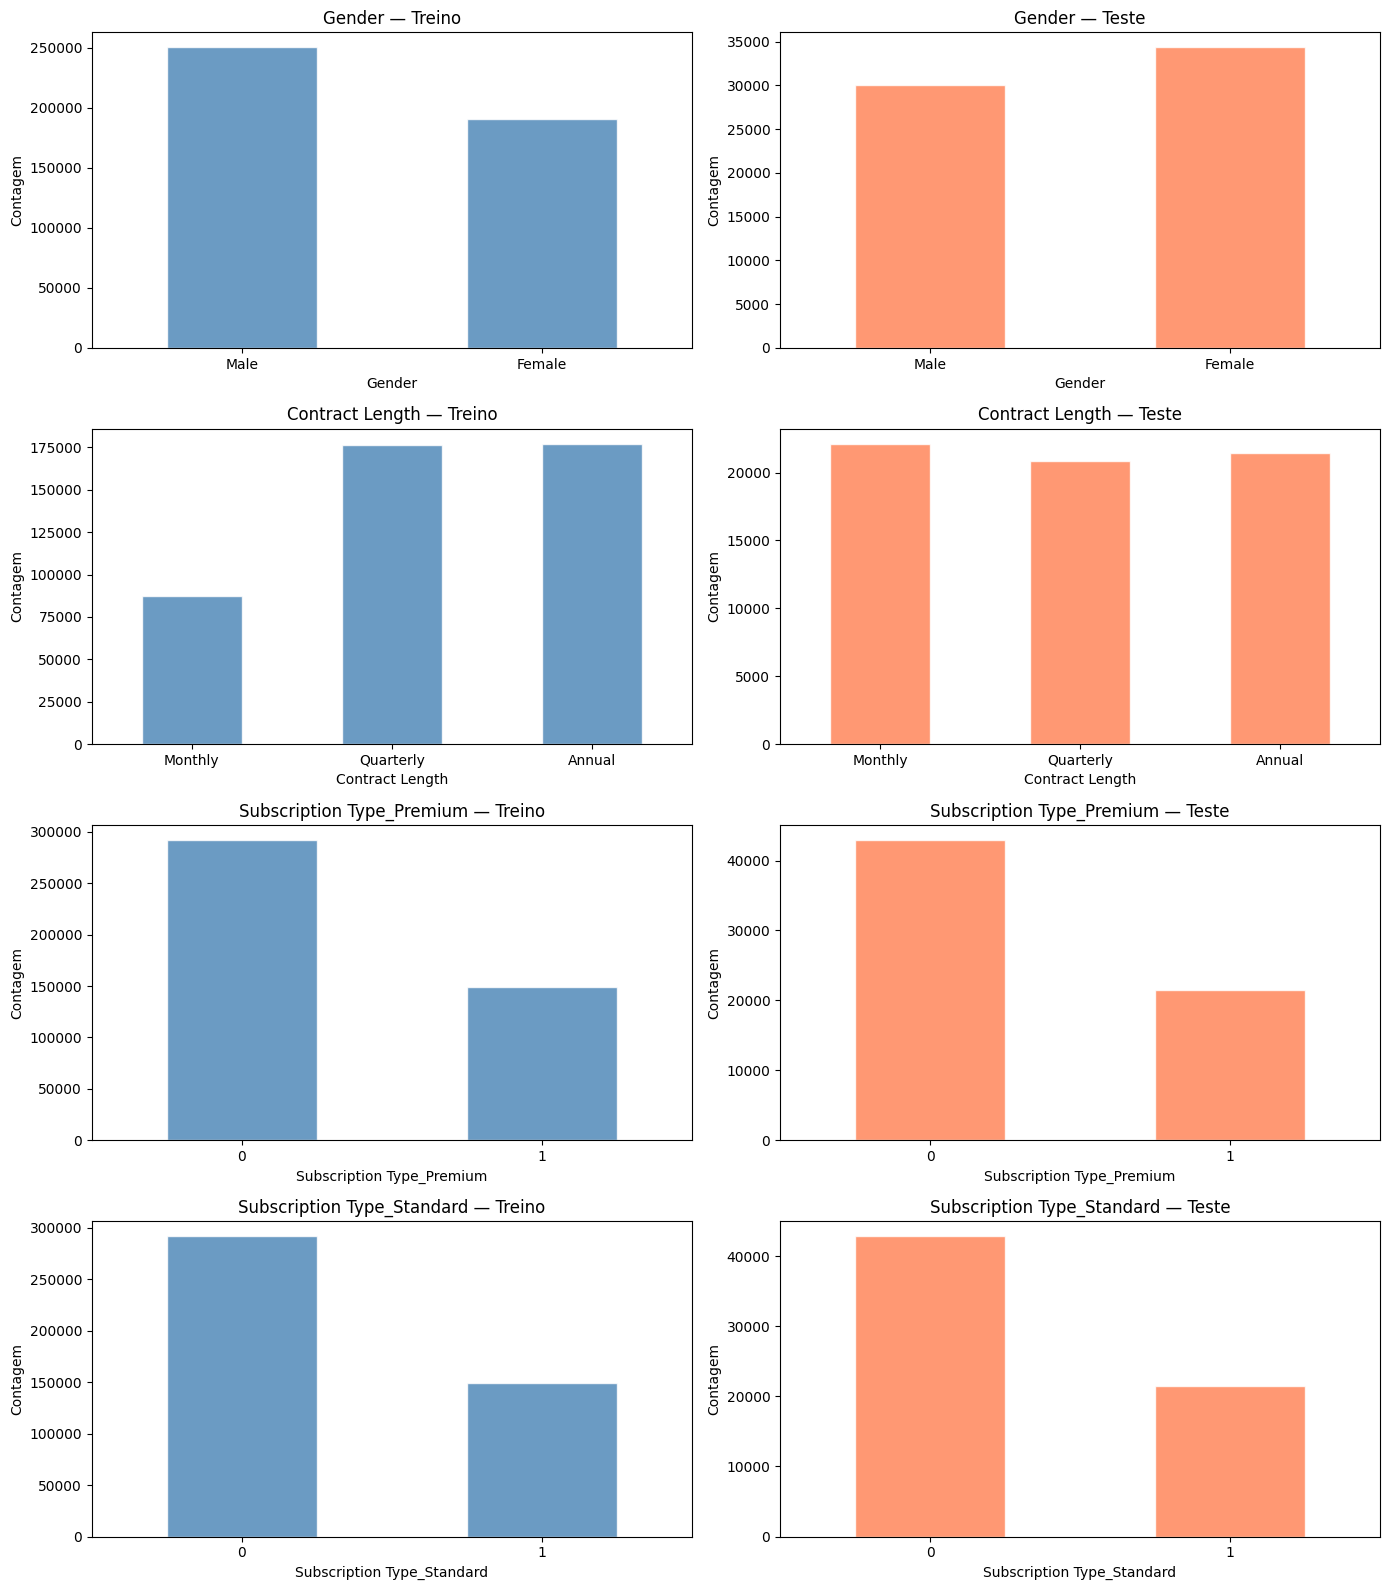

In [9]:
# Features codificadas (ex-categóricas): Countplot com labels legíveis
cols_encoded = ['Gender', 'Contract Length', 'Subscription Type_Premium', 'Subscription Type_Standard']

fig, axes = plt.subplots(len(cols_encoded), 2, figsize=(14, 4 * len(cols_encoded)))

for i, col in enumerate(cols_encoded):
    for j, (df, nome, cor) in enumerate([(df_treino, 'Treino', 'steelblue'), (df_teste, 'Teste', 'coral')]):
        contagem = df[col].value_counts().sort_index()
        contagem.plot.bar(ax=axes[i, j], color=cor, edgecolor='white', alpha=0.8)
        axes[i, j].set_title(f'{col} — {nome}')
        axes[i, j].set_ylabel('Contagem')
        
        # Substituir rótulos numéricos pelos nomes originais
        if col in labels:
            tick_labels = [labels[col].get(int(v.get_text()), v.get_text()) for v in axes[i, j].get_xticklabels()]
            axes[i, j].set_xticklabels(tick_labels, rotation=0)
        else:
            axes[i, j].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_countplot_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

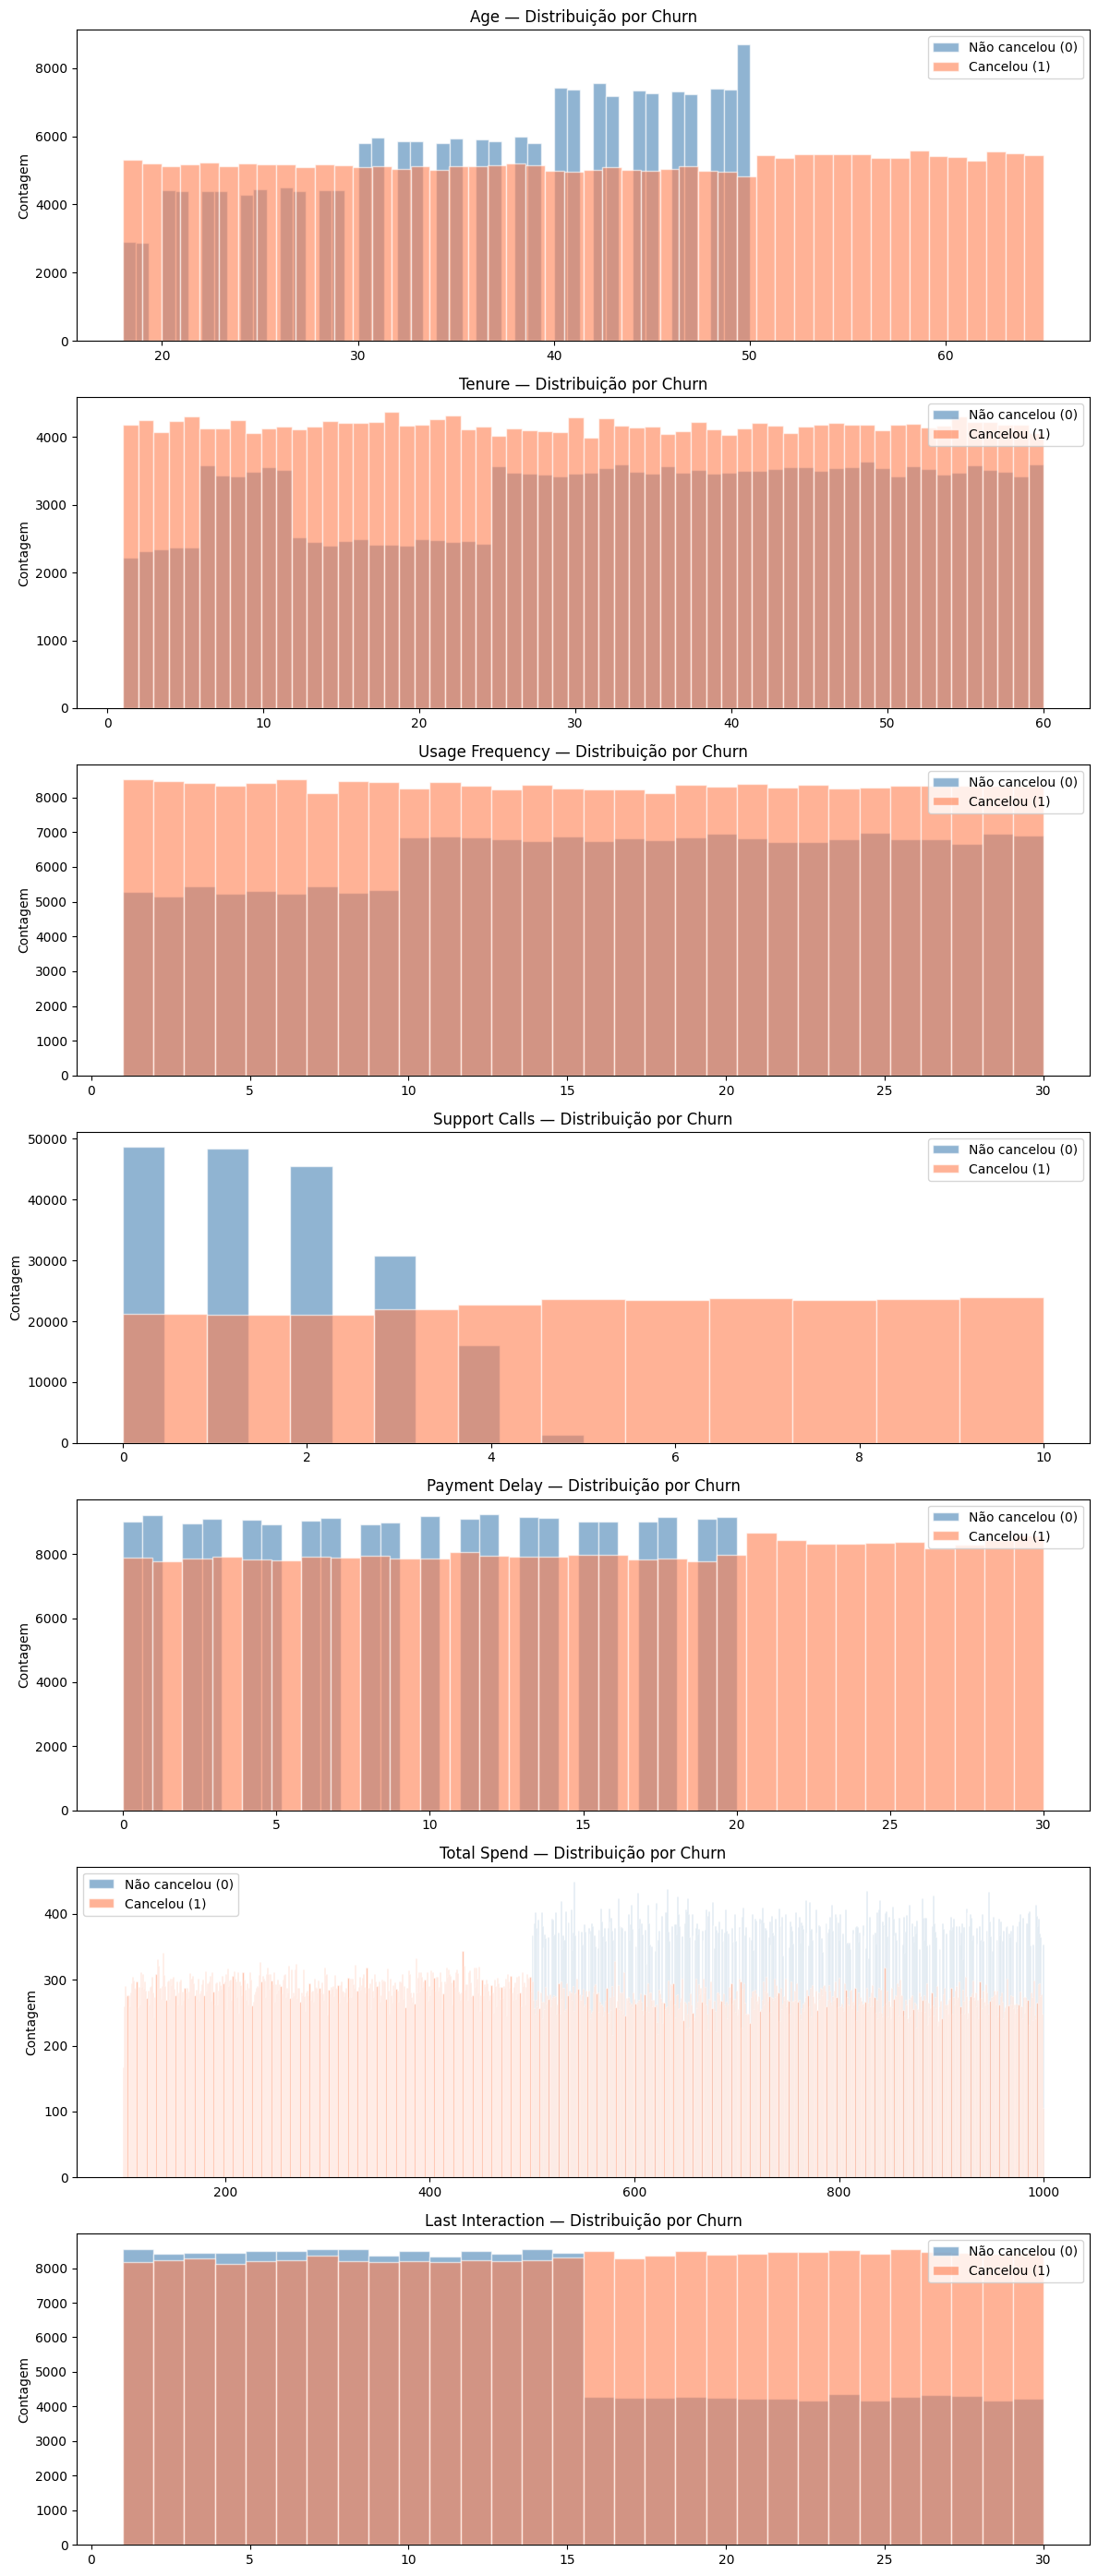

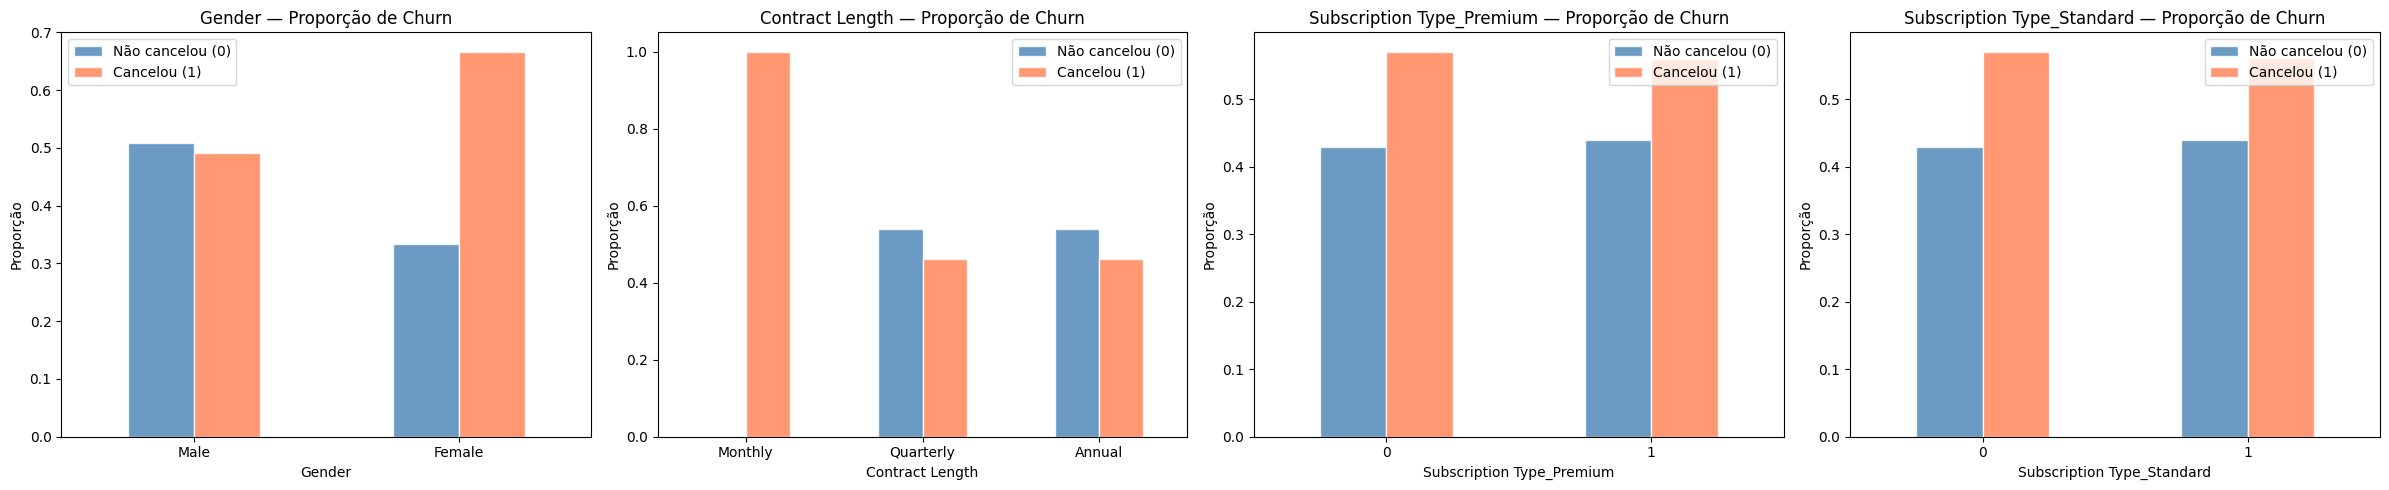

In [10]:
# Distribuição por Churn — features contínuas
fig, axes = plt.subplots(len(cols_continuas), 1, figsize=(12, 4 * len(cols_continuas)))

for i, col in enumerate(cols_continuas):
    n_bins = df_treino[col].nunique()
    df_treino[df_treino['Churn'] == 0][col].plot.hist(
        ax=axes[i], bins=n_bins, alpha=0.6, color='steelblue', label='Não cancelou (0)', edgecolor='white'
    )
    df_treino[df_treino['Churn'] == 1][col].plot.hist(
        ax=axes[i], bins=n_bins, alpha=0.6, color='coral', label='Cancelou (1)', edgecolor='white'
    )
    axes[i].set_title(f'{col} — Distribuição por Churn')
    axes[i].set_ylabel('Contagem')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_distribuicao_por_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Distribuição por Churn — features codificadas
fig, axes = plt.subplots(1, len(cols_encoded), figsize=(6 * len(cols_encoded), 5))

for i, col in enumerate(cols_encoded):
    ct = pd.crosstab(df_treino[col], df_treino['Churn'], normalize='index')
    ct.plot.bar(ax=axes[i], color=['steelblue', 'coral'], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col} — Proporção de Churn')
    axes[i].set_ylabel('Proporção')
    axes[i].legend(['Não cancelou (0)', 'Cancelou (1)'])
    
    if col in labels:
        tick_labels = [labels[col].get(int(v.get_text()), v.get_text()) for v in axes[i].get_xticklabels()]
        axes[i].set_xticklabels(tick_labels, rotation=0)
    else:
        axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_churn_por_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

## Investigação de Problemas

Problemas identificados durante a análise exploratória que precisam de investigação formal antes de prosseguir.

### 5.1 — Granularidade: Total Spend

Os dados de treino originais tinham `Total Spend` com valores decimais (float64), enquanto o teste tinha valores inteiros. A conversão `float → int` no passo de ajustes iniciais já igualou a granularidade. Vamos confirmar que o tratamento foi efetivo.

Treino: 901 valores únicos
Teste:  901 valores únicos

Treino (primeiros 10 valores ordenados):
[np.int64(100), np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109)]

Teste (primeiros 10 valores ordenados):
[np.int64(100), np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109)]



--- Antes do tratamento ---
Treino original: 68363 valores únicos (dtype: float64)
Primeiros 10 valores ordenados:
[np.float64(100.0), np.float64(100.02), np.float64(100.06), np.float64(100.07), np.float64(100.08), np.float64(100.09), np.float64(100.11), np.float64(100.12), np.float64(100.13), np.float64(100.16)]


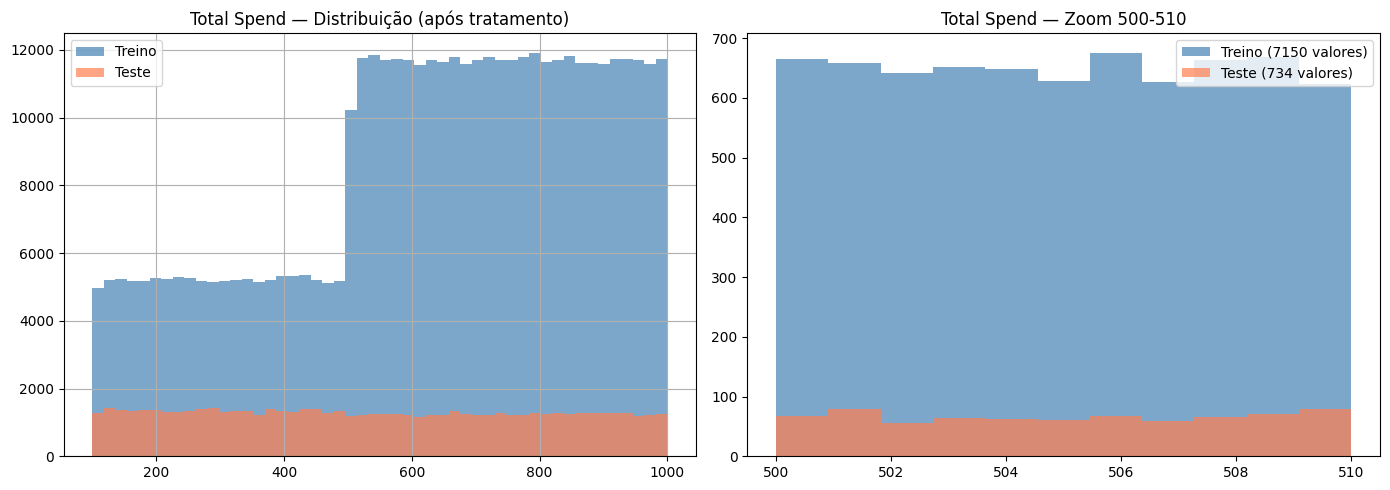

In [11]:
# Verificar granularidade atual (após conversão int)
print(f"Treino: {df_treino['Total Spend'].nunique()} valores únicos")
print(f"Teste:  {df_teste['Total Spend'].nunique()} valores únicos")

print("\nTreino (primeiros 10 valores ordenados):")
print(sorted(df_treino['Total Spend'].unique())[:10])
print("\nTeste (primeiros 10 valores ordenados):")
print(sorted(df_teste['Total Spend'].unique())[:10])

# Comparar dados originais (recarregar para mostrar a diferença)
df_original = pd.read_csv('../material/lab2_cmc13_dados_treinamento.csv')
print(f"\n--- Antes do tratamento ---")
print(f"Treino original: {df_original['Total Spend'].nunique()} valores únicos (dtype: {df_original['Total Spend'].dtype})")
print(f"Primeiros 10 valores ordenados:")
print(sorted(df_original['Total Spend'].dropna().unique())[:10])

# Histograma sobreposto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_treino['Total Spend'].hist(ax=axes[0], bins=50, alpha=0.7, color='steelblue', label='Treino')
df_teste['Total Spend'].hist(ax=axes[0], bins=50, alpha=0.7, color='coral', label='Teste')
axes[0].set_title('Total Spend — Distribuição (após tratamento)')
axes[0].legend()

# Zoom para confirmar granularidade igual
faixa_treino = df_treino['Total Spend'][(df_treino['Total Spend'] >= 500) & (df_treino['Total Spend'] <= 510)]
faixa_teste = df_teste['Total Spend'][(df_teste['Total Spend'] >= 500) & (df_teste['Total Spend'] <= 510)]
axes[1].hist(faixa_treino, bins=11, alpha=0.7, color='steelblue', label=f'Treino ({len(faixa_treino)} valores)')
axes[1].hist(faixa_teste, bins=11, alpha=0.7, color='coral', label=f'Teste ({len(faixa_teste)} valores)')
axes[1].set_title('Total Spend — Zoom 500-510')
axes[1].legend()
plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_granularidade_total_spend.png', dpi=150, bbox_inches='tight')
plt.show()

del df_original

**Resultado:** A conversão `float → int` nos ajustes iniciais já resolveu o problema de granularidade. Treino e teste agora têm os mesmos 901 valores únicos (inteiros de 100 a 1000). Nenhum tratamento adicional necessário.

### 5.2 — Separação perfeita: Contract Length

Nos gráficos de proporção de churn por categoria, `Contract Length = Monthly` apresentou taxa de churn próxima a 100% no treino. Se esse padrão não se mantiver no teste, há risco de overfitting nessa feature.

                 Treino (% churn)  Teste (% churn)  Treino (n)  Teste (n)
Contract Length                                                          
Monthly                     100.0             51.6       87104      22130
Quarterly                    46.0             44.0      176530      20834
Annual                       46.1             46.2      177198      21410


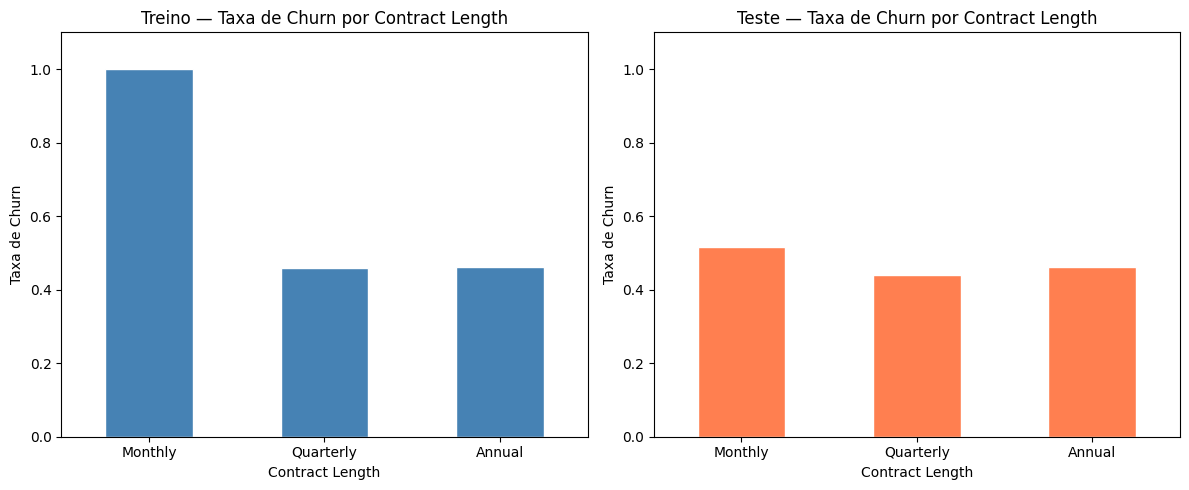

In [12]:
# Taxa de churn por Contract Length — treino vs teste
churn_treino = df_treino.groupby('Contract Length')['Churn'].mean()
churn_teste = df_teste.groupby('Contract Length')['Churn'].mean()

comparacao = pd.DataFrame({
    'Treino (% churn)': (churn_treino * 100).round(1),
    'Teste (% churn)': (churn_teste * 100).round(1),
    'Treino (n)': df_treino.groupby('Contract Length')['Churn'].count(),
    'Teste (n)': df_teste.groupby('Contract Length')['Churn'].count()
})
comparacao.index = comparacao.index.map(labels['Contract Length'])
print(comparacao.to_string())

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
churn_treino.plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Treino — Taxa de Churn por Contract Length')
axes[0].set_ylabel('Taxa de Churn')
axes[0].set_xticklabels([labels['Contract Length'][int(float(v.get_text()))] for v in axes[0].get_xticklabels()], rotation=0)
axes[0].set_ylim(0, 1.1)

churn_teste.plot.bar(ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Teste — Taxa de Churn por Contract Length')
axes[1].set_ylabel('Taxa de Churn')
axes[1].set_xticklabels([labels['Contract Length'][int(float(v.get_text()))] for v in axes[1].get_xticklabels()], rotation=0)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_separacao_perfeita_contract.png', dpi=150, bbox_inches='tight')
plt.show()

**Resultado:** Separação perfeita confirmada — Monthly tem **100% churn no treino** (87.104 amostras) mas apenas **51.6% no teste** (22.130 amostras). Quarterly e Annual se comportam de forma consistente entre treino (~46%) e teste (~44-46%).

O padrão do treino não generaliza para o teste. Qualquer modelo vai aprender "Monthly = churn garantido" e errar metade das predições no teste.

> **DECISÃO SUSPENSA (dados experimentais):** A remoção de Contract Length foi revertida.
> Nos experimentos com os modelos (notebooks 2A, 2B, 2C), a remoção dessa feature
> resultou em modelos que preveem quase tudo como classe 1 (recall ~100%, acurácia ~52%, Kappa ~0.09).
> A feature será mantida para que os modelos tenham informação suficiente para discriminar as classes.
> O risco de overfitting será monitorado via MLflow.

### 5.3 — Teste de Data Leakage

Suspeita: `Support Calls` e `Contract Length` podem ser **consequência** do churn, não causa. Se uma árvore de decisão rasa (max_depth=3) usando apenas essas 2 features atingir acurácia > 95%, o modelo está "lendo a resposta" em vez de aprender padrões reais.

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Teste com apenas Support Calls + Contract Length
X_leak = df_treino[['Support Calls', 'Contract Length']]
y_leak = df_treino['Churn']
X_leak_teste = df_teste[['Support Calls', 'Contract Length']]
y_leak_teste = df_teste['Churn']

arvore = DecisionTreeClassifier(max_depth=3, random_state=42)
arvore.fit(X_leak, y_leak)

acc_treino = accuracy_score(y_leak, arvore.predict(X_leak))
acc_teste = accuracy_score(y_leak_teste, arvore.predict(X_leak_teste))

print(f"Acurácia com apenas 2 features (Support Calls + Contract Length):")
print(f"  Treino: {acc_treino:.4f}")
print(f"  Teste:  {acc_teste:.4f}")
print(f"\nSe acurácia > 95%, há forte suspeita de data leakage.\n")
print("Relatório no teste:")
print(classification_report(y_leak_teste, arvore.predict(X_leak_teste)))

# Comparar com modelo usando TODAS as features
X_all = df_treino.drop(columns=['Churn'])
X_all_teste = df_teste.drop(columns=['Churn'])

arvore_all = DecisionTreeClassifier(max_depth=3, random_state=42)
arvore_all.fit(X_all, df_treino['Churn'])

acc_all_treino = accuracy_score(df_treino['Churn'], arvore_all.predict(X_all))
acc_all_teste = accuracy_score(df_teste['Churn'], arvore_all.predict(X_all_teste))

print(f"\nAcurácia com TODAS as features:")
print(f"  Treino: {acc_all_treino:.4f}")
print(f"  Teste:  {acc_all_teste:.4f}")

Acurácia com apenas 2 features (Support Calls + Contract Length):
  Treino: 0.8427
  Teste:  0.6173

Se acurácia > 95%, há forte suspeita de data leakage.

Relatório no teste:
              precision    recall  f1-score   support

           0       0.79      0.37      0.50     33881
           1       0.56      0.89      0.69     30493

    accuracy                           0.62     64374
   macro avg       0.68      0.63      0.60     64374
weighted avg       0.68      0.62      0.59     64374




Acurácia com TODAS as features:
  Treino: 0.9222
  Teste:  0.5853


**Resultado:** A acurácia com apenas 2 features ficou em **84.3% no treino** e **61.7% no teste** — abaixo do limiar de 95%, então **não há data leakage clássico**. Support Calls e Contract Length não "entregam a resposta" sozinhas.

No entanto, a queda treino→teste é preocupante: **23 pontos** com 2 features e **34 pontos** com todas. Adicionar mais features piorou o teste (de 61.7% para 58.5%), indicando que as features extras ajudam o modelo a decorar o treino em vez de generalizar. Esse comportamento reforça a decisão de remover Contract Length (principal responsável pelo overfitting). Support Calls será mantida — não apresenta separação perfeita, e os modelos mostrarão se o data shift afeta o desempenho.

### 5.4 — Desbalanceamento: Contract Length

`Monthly` representa ~20% das amostras no treino vs ~33% no teste. Combinado com o comportamento extremo (≈100% churn), essa diferença de proporção pode afetar a generalização dos modelos.

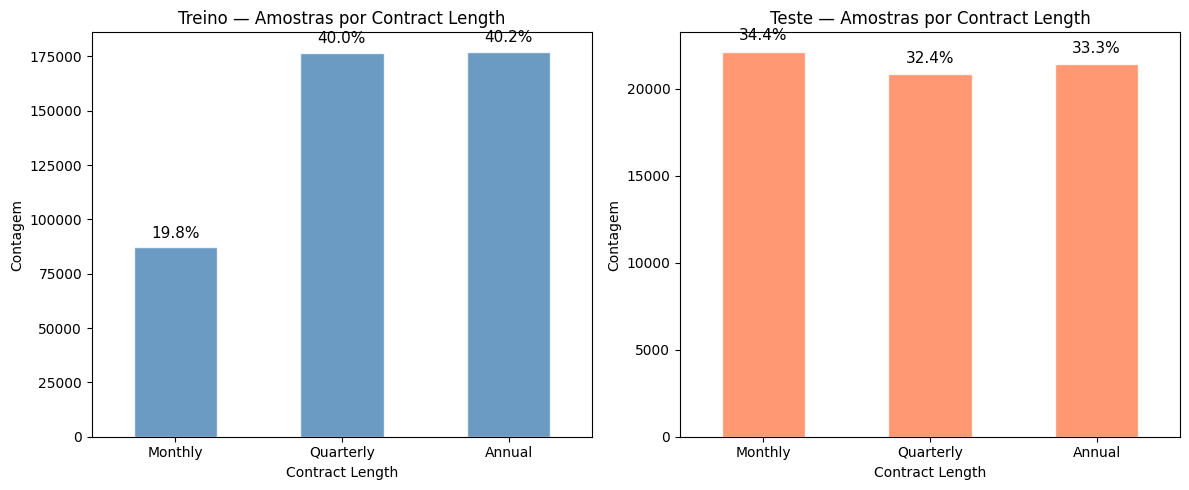

In [14]:
# Contagem e proporção por Contract Length — treino vs teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, nome, cor in [(axes[0], df_treino, 'Treino', 'steelblue'), (axes[1], df_teste, 'Teste', 'coral')]:
    contagem = df['Contract Length'].value_counts().sort_index()
    bars = contagem.plot.bar(ax=ax, color=cor, edgecolor='white', alpha=0.8)
    ax.set_title(f'{nome} — Amostras por Contract Length')
    ax.set_ylabel('Contagem')
    ax.set_xticklabels([labels['Contract Length'][int(float(v.get_text()))] for v in ax.get_xticklabels()], rotation=0)

    # Adicionar % em cima de cada barra
    total = len(df)
    for bar, val in zip(bars.patches, contagem):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{val/total*100:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_desbalanceamento_contract.png', dpi=150, bbox_inches='tight')
plt.show()

**Resultado:** A proporção de Monthly no treino (~20%) é muito diferente do teste (~33%), enquanto Quarterly e Annual são ~40% no treino e ~33% no teste.

> **DECISÃO SUSPENSA (dados experimentais):** Apesar da diferença de distribuição e da separação
> perfeita (5.2), a remoção de Contract Length prejudicou significativamente o desempenho dos modelos.
> A feature será mantida — ver nota na seção 5.2.

In [15]:
# SUSPENSA — Remoção de Contract Length revertida (ver markdown acima)
# A análise indicava remoção, mas os modelos ficaram sem poder preditivo suficiente.
# df_treino = df_treino.drop(columns=['Contract Length'])
# df_teste = df_teste.drop(columns=['Contract Length'])

print(f'Treino: {df_treino.shape} | Teste: {df_teste.shape}')
print(f'Contract Length MANTIDA nos dados.')

Treino: (440832, 12) | Teste: (64374, 12)
Contract Length MANTIDA nos dados.


## Análise de Correlação

Correlação calculada com todas as features disponíveis após os ajustes iniciais (encoding, remoção de CustomerID).

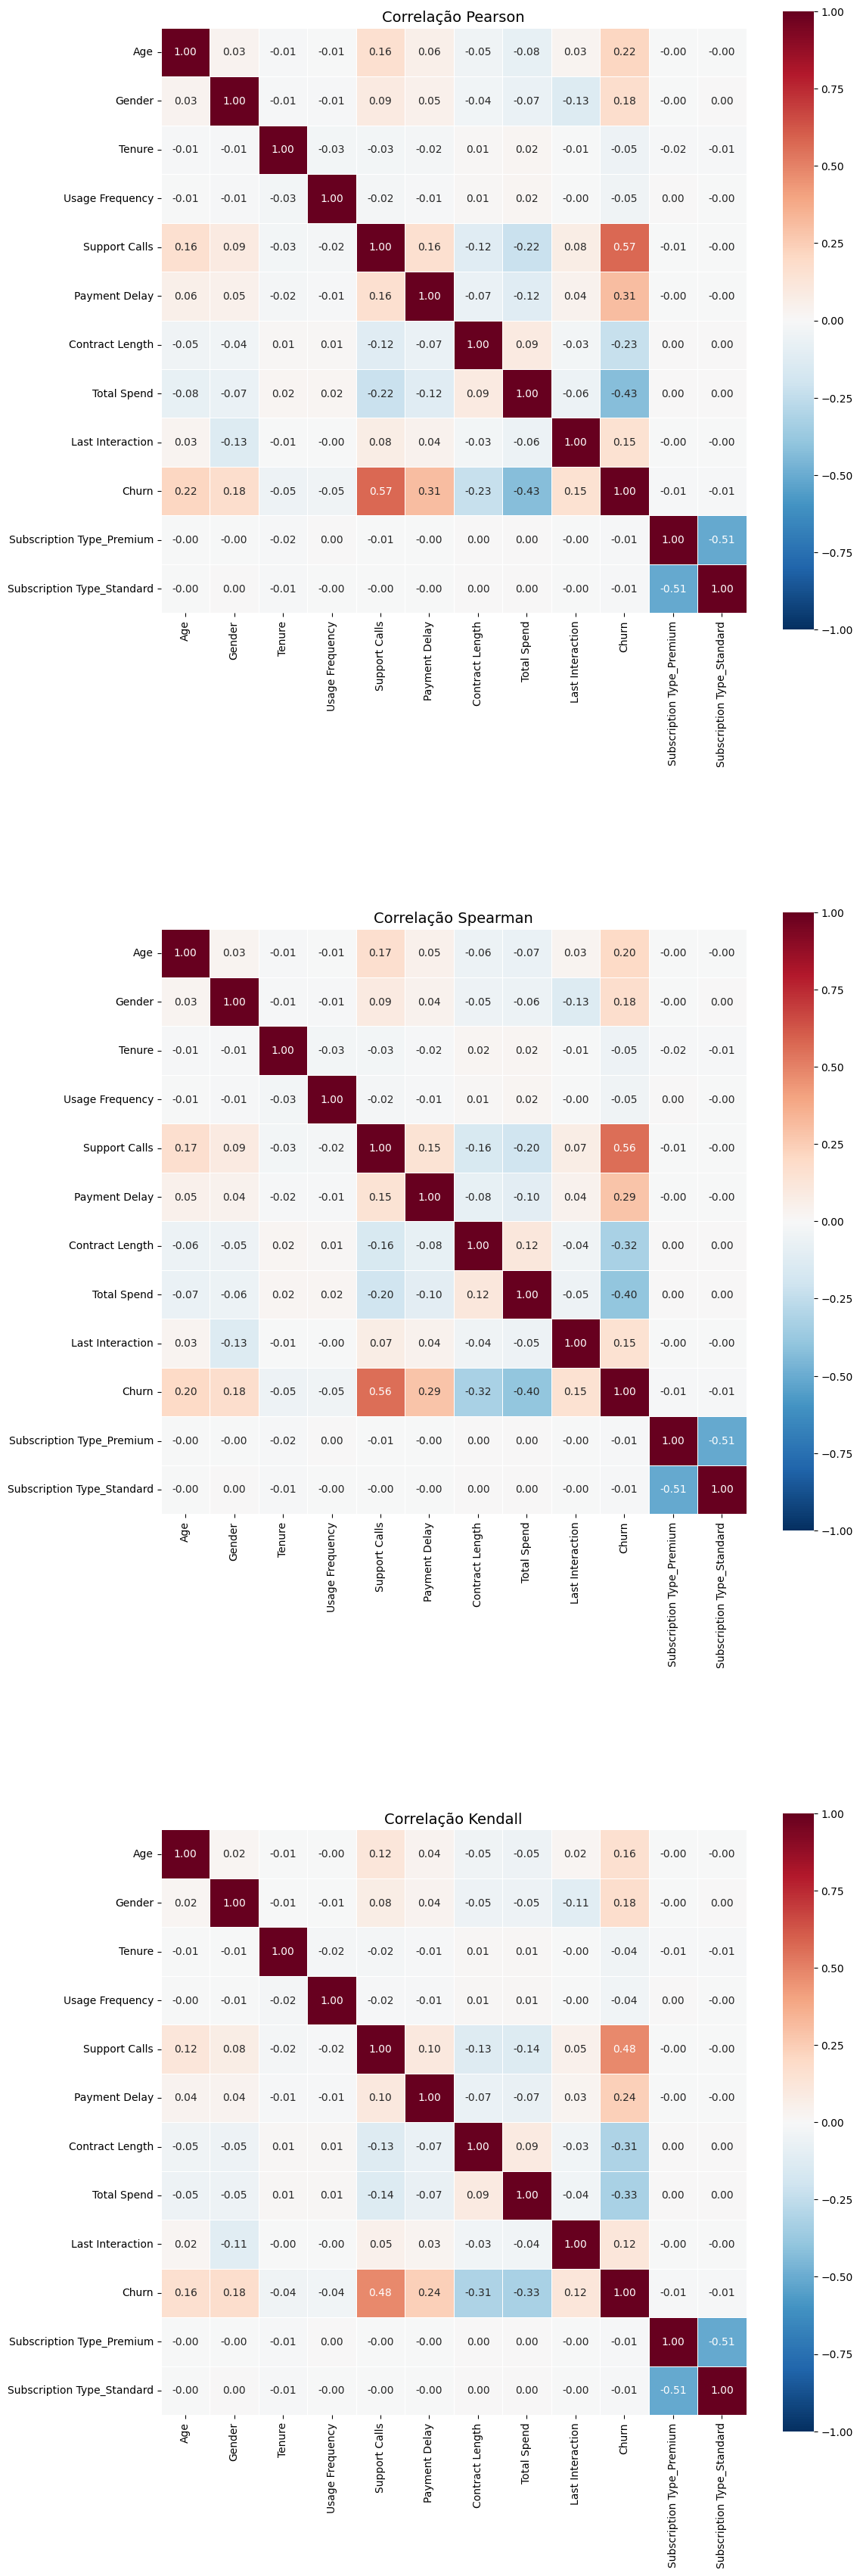

In [16]:
# Correlação — Pearson, Spearman, Kendall
metodos = ['pearson', 'spearman', 'kendall']

fig, axes = plt.subplots(3, 1, figsize=(12, 36))

for i, metodo in enumerate(metodos):
    matriz = df_treino.corr(method=metodo)
    sns.heatmap(
        matriz, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
        vmin=-1, vmax=1, ax=axes[i], square=True,
        linewidths=0.5, cbar_kws={'shrink': 0.8}
    )
    axes[i].set_title(f'Correlação {metodo.capitalize()}', fontsize=14)

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_correlacao_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

=== Correlação Point-Biserial com Churn ===

                           correlação    p-value
Support Calls                  0.5743   0.00e+00
Total Spend                   -0.4287   0.00e+00
Payment Delay                  0.3121   0.00e+00
Contract Length               -0.2341   0.00e+00
Age                            0.2184   0.00e+00
Gender                         0.1754   0.00e+00
Last Interaction               0.1496   0.00e+00
Tenure                        -0.0519  9.58e-261
Usage Frequency               -0.0461  5.69e-206
Subscription Type_Premium     -0.0111   1.96e-13
Subscription Type_Standard    -0.0092   8.28e-10


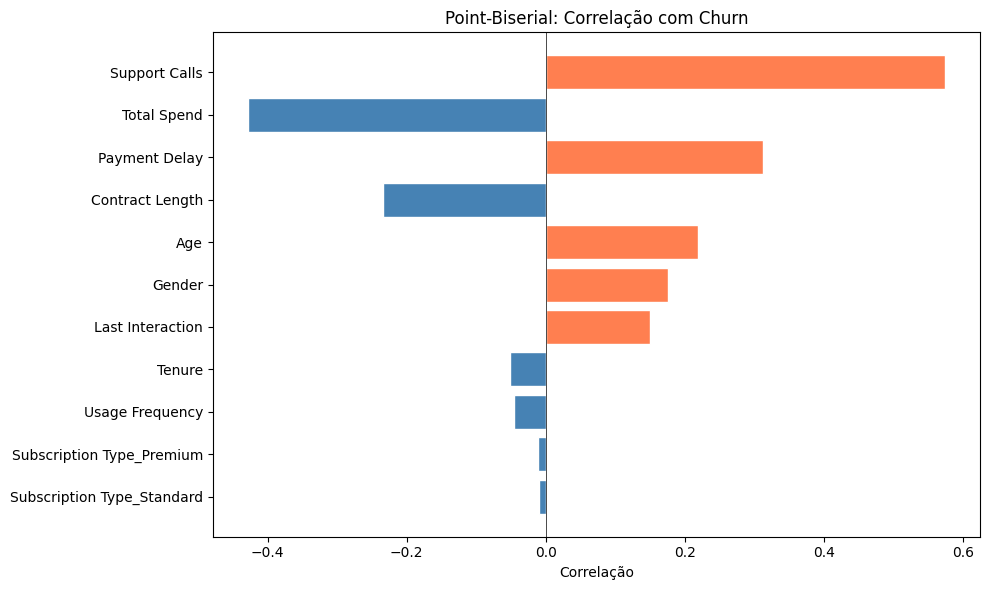

In [17]:
# Point-Biserial: correlação de cada feature com Churn
from scipy.stats import pointbiserialr

print("=== Correlação Point-Biserial com Churn ===\n")

cols_features = [c for c in df_treino.columns if c != 'Churn']

resultados = {}
for col in cols_features:
    corr, pvalue = pointbiserialr(df_treino['Churn'], df_treino[col])
    resultados[col] = {'correlação': corr, 'p-value': pvalue}

pb = pd.DataFrame(resultados).T.sort_values('correlação', key=abs, ascending=False)
pb['correlação'] = pb['correlação'].map('{:.4f}'.format)
pb['p-value'] = pb['p-value'].map('{:.2e}'.format)
print(pb.to_string())

# Visualização
fig, ax = plt.subplots(figsize=(10, 6))
vals = pd.DataFrame(resultados).T.sort_values('correlação', key=abs, ascending=True)
colors = ['coral' if v > 0 else 'steelblue' for v in vals['correlação']]
ax.barh(vals.index, vals['correlação'], color=colors, edgecolor='white')
ax.set_title('Point-Biserial: Correlação com Churn')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Correlação')
plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_point_biserial.png', dpi=150, bbox_inches='tight')
plt.show()

### Seleção de Features pela Correlação

Dois critérios para considerar a remoção de uma feature:
1. **Baixa correlação com Churn** — feature com pouco poder preditivo
2. **Alta correlação entre features** (multicolinearidade) — features redundantes que podem prejudicar alguns modelos (ex: regressão logística, SVM)

In [18]:
# === ANÁLISE COMPLETA DE CORRELAÇÃO ===

cols_features = [c for c in df_treino.columns if c != 'Churn']

# 1. Correlação de cada feature com Churn
corr_churn = {}
for col in cols_features:
    corr, pvalue = pointbiserialr(df_treino['Churn'], df_treino[col])
    corr_churn[col] = round(corr, 4)

# 2. Matriz de correlação entre features (sem Churn)
corr_features = df_treino[cols_features].corr()

# 3. Para cada feature: maior correlação com outra feature
max_corr_par = {}
for col in cols_features:
    outros = corr_features[col].drop(col).abs().sort_values(ascending=False)
    top = outros.index[0]
    max_corr_par[col] = {
        'par': top,
        'valor': round(corr_features.loc[col, top], 4)
    }

# Tabela resumo
resumo = pd.DataFrame({
    'Corr. com Churn': corr_churn,
    '|Corr. Churn|': {k: abs(v) for k, v in corr_churn.items()},
    'Par mais correlacionado': {k: v['par'] for k, v in max_corr_par.items()},
    'Corr. com par': {k: v['valor'] for k, v in max_corr_par.items()},
    '|Corr. par|': {k: abs(v['valor']) for k, v in max_corr_par.items()},
}).sort_values('|Corr. Churn|', ascending=False)

print("=== RESUMO: Correlação com Churn + Maior correlação entre features ===\n")
print(resumo.to_string())

# 4. Todos os pares de features com correlação significativa
print("\n\n=== TODOS os pares de features (|corr| > 0.05) ===\n")
pares = []
for i in range(len(cols_features)):
    for j in range(i+1, len(cols_features)):
        val = corr_features.iloc[i, j]
        if abs(val) > 0.05:
            pares.append({
                'Feature 1': cols_features[i],
                'Feature 2': cols_features[j],
                'Correlação': round(val, 4),
                '|Corr|': round(abs(val), 4)
            })

df_pares = pd.DataFrame(pares).sort_values('|Corr|', ascending=False)
print(df_pares.to_string(index=False))

=== RESUMO: Correlação com Churn + Maior correlação entre features ===

                            Corr. com Churn  |Corr. Churn|     Par mais correlacionado  Corr. com par  |Corr. par|
Support Calls                        0.5743         0.5743                 Total Spend        -0.2212       0.2212
Total Spend                         -0.4287         0.4287               Support Calls        -0.2212       0.2212
Payment Delay                        0.3121         0.3121               Support Calls         0.1629       0.1629
Contract Length                     -0.2341         0.2341               Support Calls        -0.1210       0.1210
Age                                  0.2184         0.2184               Support Calls         0.1585       0.1585
Gender                               0.1754         0.1754            Last Interaction        -0.1348       0.1348
Last Interaction                     0.1496         0.1496                      Gender        -0.1348       0.1348
Tenure  

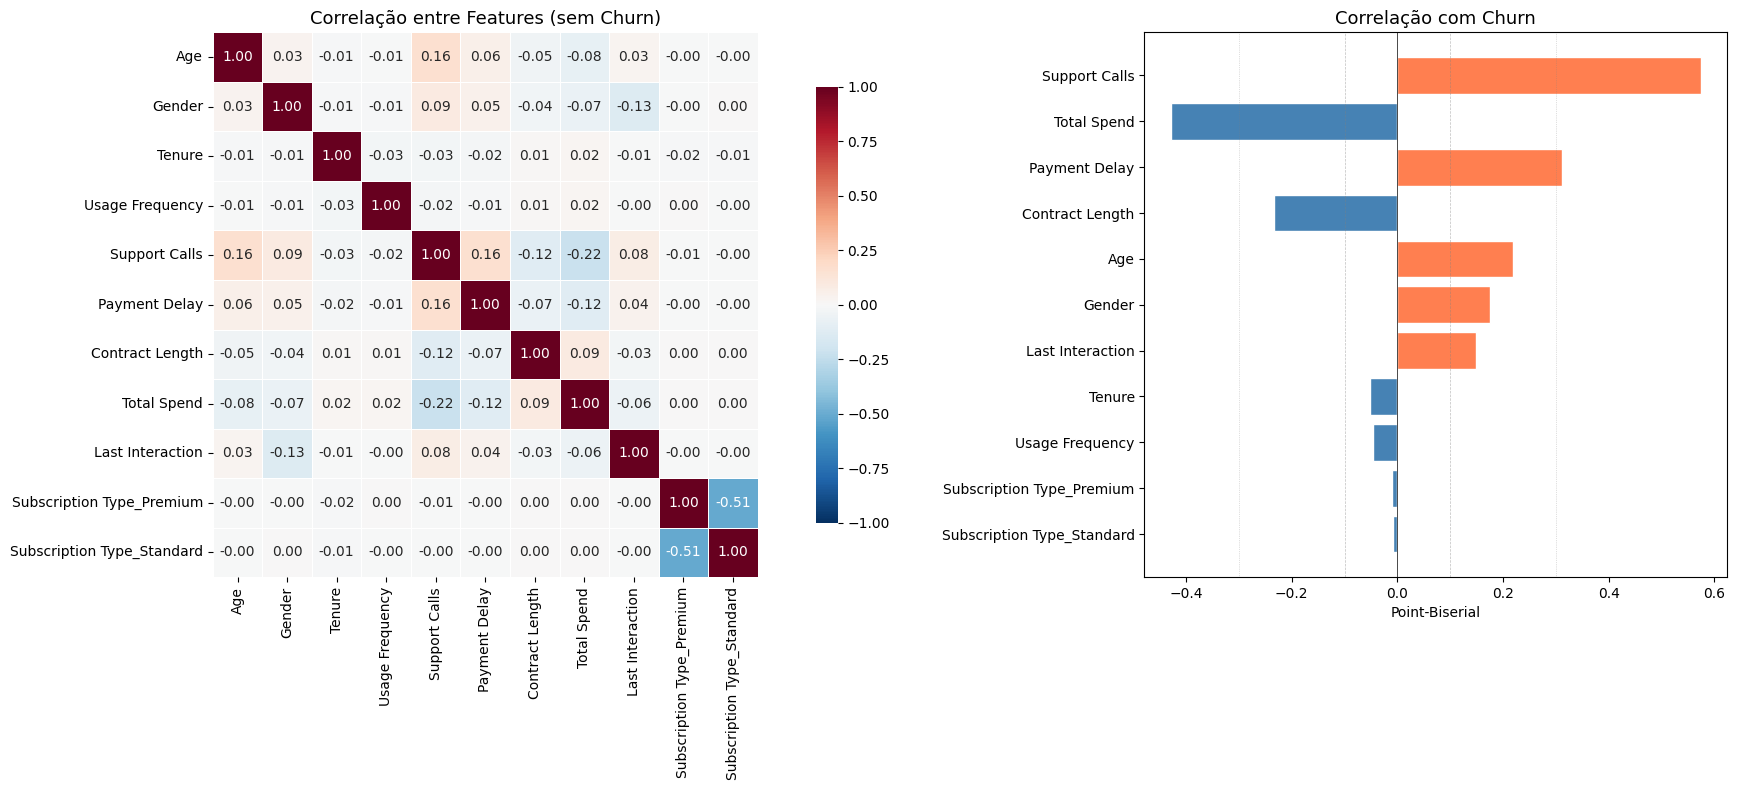

In [19]:
# Visualização: Heatmap apenas entre features (sem Churn) + barras de correlação com Churn
fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [2, 1]})

# Heatmap feature-feature
sns.heatmap(
    corr_features, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, ax=axes[0], square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Correlação entre Features (sem Churn)', fontsize=13)

# Barras de correlação com Churn
ordem = sorted(corr_churn.items(), key=lambda x: abs(x[1]))
nomes = [x[0] for x in ordem]
valores = [x[1] for x in ordem]
cores = ['coral' if v > 0 else 'steelblue' for v in valores]

axes[1].barh(nomes, valores, color=cores, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].axvline(x=0.1, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
axes[1].axvline(x=-0.1, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
axes[1].axvline(x=0.3, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)
axes[1].axvline(x=-0.3, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)
axes[1].set_title('Correlação com Churn', fontsize=13)
axes[1].set_xlabel('Point-Biserial')

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_correlacao_completa.png', dpi=150, bbox_inches='tight')
plt.show()

### Problema do One-Hot com `drop_first=True`

O `drop_first=True` suprimiu a categoria **Basic**, que virou a referência implícita (Premium=0, Standard=0). Isso causa dois problemas na análise:
1. A correlação de Basic com Churn fica **invisível** — não sabemos se Basic é relevante
2. Premium e Standard ficam com correlação artificial de -0.51 entre si (são mutuamente exclusivas)

Para analisar corretamente, reconstruímos temporariamente as 3 categorias:

=== Correlação de cada categoria do Subscription Type com Churn ===

       Subscription Type_Basic: corr=+0.0205  p=2.67e-42  |  32.4% das amostras  |  churn=58.2%
     Subscription Type_Premium: corr=-0.0111  p=1.96e-13  |  33.7% das amostras  |  churn=55.9%
    Subscription Type_Standard: corr=-0.0092  p=8.28e-10  |  33.8% das amostras  |  churn=56.1%

           Taxa de churn geral: 56.7%


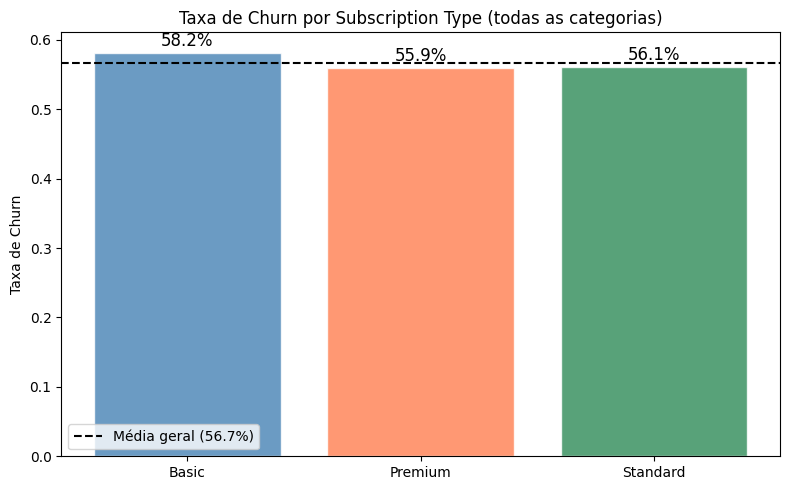

In [20]:
# Reconstruir Basic e analisar as 3 categorias separadamente
df_treino['Subscription Type_Basic'] = ((df_treino['Subscription Type_Premium'] == 0) & 
                                         (df_treino['Subscription Type_Standard'] == 0)).astype(int)

print("=== Correlação de cada categoria do Subscription Type com Churn ===\n")
for cat in ['Subscription Type_Basic', 'Subscription Type_Premium', 'Subscription Type_Standard']:
    corr, pvalue = pointbiserialr(df_treino['Churn'], df_treino[cat])
    proporcao = df_treino[cat].mean() * 100
    churn_rate = df_treino[df_treino[cat] == 1]['Churn'].mean() * 100
    print(f"{cat:>30}: corr={corr:+.4f}  p={pvalue:.2e}  |  {proporcao:.1f}% das amostras  |  churn={churn_rate:.1f}%")

# Taxa de churn geral para comparar
print(f"\n{'Taxa de churn geral':>30}: {df_treino['Churn'].mean()*100:.1f}%")

# Visualização: proporção de churn por categoria
fig, ax = plt.subplots(figsize=(8, 5))
cats = ['Basic', 'Premium', 'Standard']
churn_rates = [
    df_treino[df_treino['Subscription Type_Basic'] == 1]['Churn'].mean(),
    df_treino[df_treino['Subscription Type_Premium'] == 1]['Churn'].mean(),
    df_treino[df_treino['Subscription Type_Standard'] == 1]['Churn'].mean()
]
bars = ax.bar(cats, churn_rates, color=['steelblue', 'coral', 'seagreen'], edgecolor='white', alpha=0.8)
ax.axhline(y=df_treino['Churn'].mean(), color='black', linestyle='--', label=f'Média geral ({df_treino["Churn"].mean()*100:.1f}%)')
for bar, rate in zip(bars, churn_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{rate*100:.1f}%', ha='center', fontsize=12)
ax.set_ylabel('Taxa de Churn')
ax.set_title('Taxa de Churn por Subscription Type (todas as categorias)')
ax.legend()
plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_churn_subscription_completo.png', dpi=150, bbox_inches='tight')
plt.show()

# Remover coluna temporária
df_treino = df_treino.drop(columns=['Subscription Type_Basic'])

### Correlações não-lineares

A correlação de Pearson (e Point-Biserial) mede apenas relações **lineares**. Uma feature pode ter correlação linear fraca mas relação **monotônica** (capturada por Spearman/Kendall) ou padrão **não-monotônico** (ex: formato U) que só aparece nos gráficos de distribuição por Churn.

Comparamos os 3 métodos para as 4 features candidatas a remoção e referenciamos os gráficos de distribuição por Churn já gerados na seção de Análise Exploratória.

In [21]:
# Comparação Pearson vs Spearman vs Kendall para as 4 features fracas
from scipy.stats import spearmanr, kendalltau

candidatas = ['Tenure', 'Usage Frequency', 'Subscription Type_Premium', 'Subscription Type_Standard']

print("=== Pearson vs Spearman vs Kendall — Features com correlação linear fraca ===\n")
print(f"{'Feature':>30} | {'Pearson':>10} | {'Spearman':>10} | {'Kendall':>10} | Mudou?")
print("-" * 85)

for col in candidatas:
    pearson = df_treino[col].corr(df_treino['Churn'])
    spearman, _ = spearmanr(df_treino[col], df_treino['Churn'])
    kendall, _ = kendalltau(df_treino[col], df_treino['Churn'])
    
    mudou = 'SIM' if abs(spearman) > abs(pearson) * 1.5 else 'não'
    print(f"{col:>30} | {pearson:>+10.4f} | {spearman:>+10.4f} | {kendall:>+10.4f} | {mudou}")

# Mesma análise para TODAS as features (contexto)
print("\n\n=== Mesma comparação para TODAS as features ===\n")
print(f"{'Feature':>30} | {'Pearson':>10} | {'Spearman':>10} | {'Kendall':>10}")
print("-" * 75)

for col in [c for c in df_treino.columns if c != 'Churn']:
    pearson = df_treino[col].corr(df_treino['Churn'])
    spearman, _ = spearmanr(df_treino[col], df_treino['Churn'])
    kendall, _ = kendalltau(df_treino[col], df_treino['Churn'])
    print(f"{col:>30} | {pearson:>+10.4f} | {spearman:>+10.4f} | {kendall:>+10.4f}")

=== Pearson vs Spearman vs Kendall — Features com correlação linear fraca ===

                       Feature |    Pearson |   Spearman |    Kendall | Mudou?
-------------------------------------------------------------------------------------
                        Tenure |    -0.0519 |    -0.0516 |    -0.0425 | não


               Usage Frequency |    -0.0461 |    -0.0457 |    -0.0379 | não
     Subscription Type_Premium |    -0.0111 |    -0.0111 |    -0.0111 | não
    Subscription Type_Standard |    -0.0092 |    -0.0092 |    -0.0092 | não


=== Mesma comparação para TODAS as features ===

                       Feature |    Pearson |   Spearman |    Kendall
---------------------------------------------------------------------------


                           Age |    +0.2184 |    +0.1962 |    +0.1620
                        Gender |    +0.1754 |    +0.1754 |    +0.1754


                        Tenure |    -0.0519 |    -0.0516 |    -0.0425
               Usage Frequency |    -0.0461 |    -0.0457 |    -0.0379


                 Support Calls |    +0.5743 |    +0.5584 |    +0.4804
                 Payment Delay |    +0.3121 |    +0.2887 |    +0.2397


               Contract Length |    -0.2341 |    -0.3215 |    -0.3051
                   Total Spend |    -0.4287 |    -0.3979 |    -0.3251


              Last Interaction |    +0.1496 |    +0.1486 |    +0.1234
     Subscription Type_Premium |    -0.0111 |    -0.0111 |    -0.0111
    Subscription Type_Standard |    -0.0092 |    -0.0092 |    -0.0092


**Conclusões da análise de correlação:**

**Subscription Type:**
- Com `drop_first=True`, Basic ficou oculta. A análise com as 3 categorias revelou taxas de churn quase idênticas: Basic=58.2%, Premium=55.9%, Standard=56.1% (média geral=56.7%). Subscription Type não discrimina churn.

**Correlações não-lineares (Pearson vs Spearman vs Kendall):**
- Nenhuma das 4 features fracas apresentou mudança significativa entre os métodos — a relação é genuinamente fraca, não há padrão monotônico oculto.
- As features fortes (Support Calls, Total Spend, Payment Delay) também mantêm valores consistentes entre métodos, confirmando que a relação com Churn é predominantemente linear.

> **DECISÃO SUSPENSA (dados experimentais):** A análise de correlação indicava remover
> Tenure (corr=0.05), Usage Frequency (corr=0.05), Subscription Type_Premium (corr=0.01)
> e Subscription Type_Standard (corr=0.01) por baixa correlação com Churn.
>
> No entanto, ao treinar os modelos apenas com as 6 features restantes (Age, Gender,
> Support Calls, Payment Delay, Total Spend, Last Interaction), todos os classificadores
> (DecisionTree, MLP, RandomForest) apresentaram desempenho quase aleatório
> (acurácia ~52%, Kappa ~0.09). Correlação linear fraca não significa ausência de
> poder preditivo — os modelos podem capturar interações não-lineares entre features.
>
> **Todas as features serão mantidas.** O impacto será avaliado via MLflow comparando
> runs com 6 vs 11 features.

In [22]:
# SUSPENSA — Remoção de features revertida (ver markdown acima)
# A correlação linear fraca não implica ausência de poder preditivo.
# cols_remover = ['Tenure', 'Usage Frequency', 'Subscription Type_Premium', 'Subscription Type_Standard']
# df_treino = df_treino.drop(columns=cols_remover)
# df_teste = df_teste.drop(columns=cols_remover)

print(f'Treino: {df_treino.shape} | Teste: {df_teste.shape}')
print(f'TODAS as features mantidas: {[c for c in df_treino.columns if c != "Churn"]}')

Treino: (440832, 12) | Teste: (64374, 12)
TODAS as features mantidas: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Contract Length', 'Total Spend', 'Last Interaction', 'Subscription Type_Premium', 'Subscription Type_Standard']


**Análise:** *(atualizar após rodar as células acima com os resultados reais)*

**Correlação com Churn:**
- Linhas tracejadas (--) marcam |corr| = 0.1, pontilhadas (:) marcam |corr| = 0.3
- Features à direita da linha pontilhada: correlação forte
- Features entre as linhas: correlação moderada
- Features perto do zero: correlação fraca

**Correlação entre features (heatmap):**
- Valores próximos de 0 (branco): features independentes entre si
- Valores altos positivos/negativos (vermelho/azul forte): features redundantes (multicolinearidade)

**Decisão do grupo:** *(preencher após análise dos gráficos e tabelas)*

## Dados Finais

Visão geral das features que serão enviadas para os modelos, após todos os tratamentos e remoções.

In [23]:
# Resumo dos dados finais
print(f"Treino: {df_treino.shape[0]} amostras, {df_treino.shape[1] - 1} features + target")
print(f"Teste:  {df_teste.shape[0]} amostras, {df_teste.shape[1] - 1} features + target")
print(f"\nFeatures: {[c for c in df_treino.columns if c != 'Churn']}")
print(f"Target: Churn")
print(f"\nDistribuição do target:")
print(f"  Treino — Churn=1: {df_treino['Churn'].mean()*100:.1f}% | Churn=0: {(1-df_treino['Churn'].mean())*100:.1f}%")
print(f"  Teste  — Churn=1: {df_teste['Churn'].mean()*100:.1f}% | Churn=0: {(1-df_teste['Churn'].mean())*100:.1f}%")
df_treino.describe().round(2)

Treino: 440832 amostras, 11 features + target
Teste:  64374 amostras, 11 features + target

Features: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Contract Length', 'Total Spend', 'Last Interaction', 'Subscription Type_Premium', 'Subscription Type_Standard']
Target: Churn

Distribuição do target:
  Treino — Churn=1: 56.7% | Churn=0: 43.3%
  Teste  — Churn=1: 47.4% | Churn=0: 52.6%


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Contract Length,Total Spend,Last Interaction,Churn,Subscription Type_Premium,Subscription Type_Standard
count,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00
mean,39.37,0.43,31.26,15.81,3.60,12.97,6.22,631.34,14.48,0.57,0.34,0.34
std,12.44,0.50,17.26,8.59,3.07,8.26,4.79,240.72,8.60,0.50,0.47,0.47
min,18.00,0.00,1.00,1.00,0.00,0.00,1.00,100.00,1.00,0.00,0.00,0.00
25%,29.00,0.00,16.00,9.00,1.00,6.00,3.00,480.00,7.00,0.00,0.00,0.00
50%,39.00,0.00,32.00,16.00,3.00,12.00,3.00,661.00,14.00,1.00,0.00,0.00
75%,48.00,1.00,46.00,23.00,6.00,19.00,12.00,830.00,22.00,1.00,1.00,1.00
max,65.00,1.00,60.00,30.00,10.00,30.00,12.00,1000.00,30.00,1.00,1.00,1.00


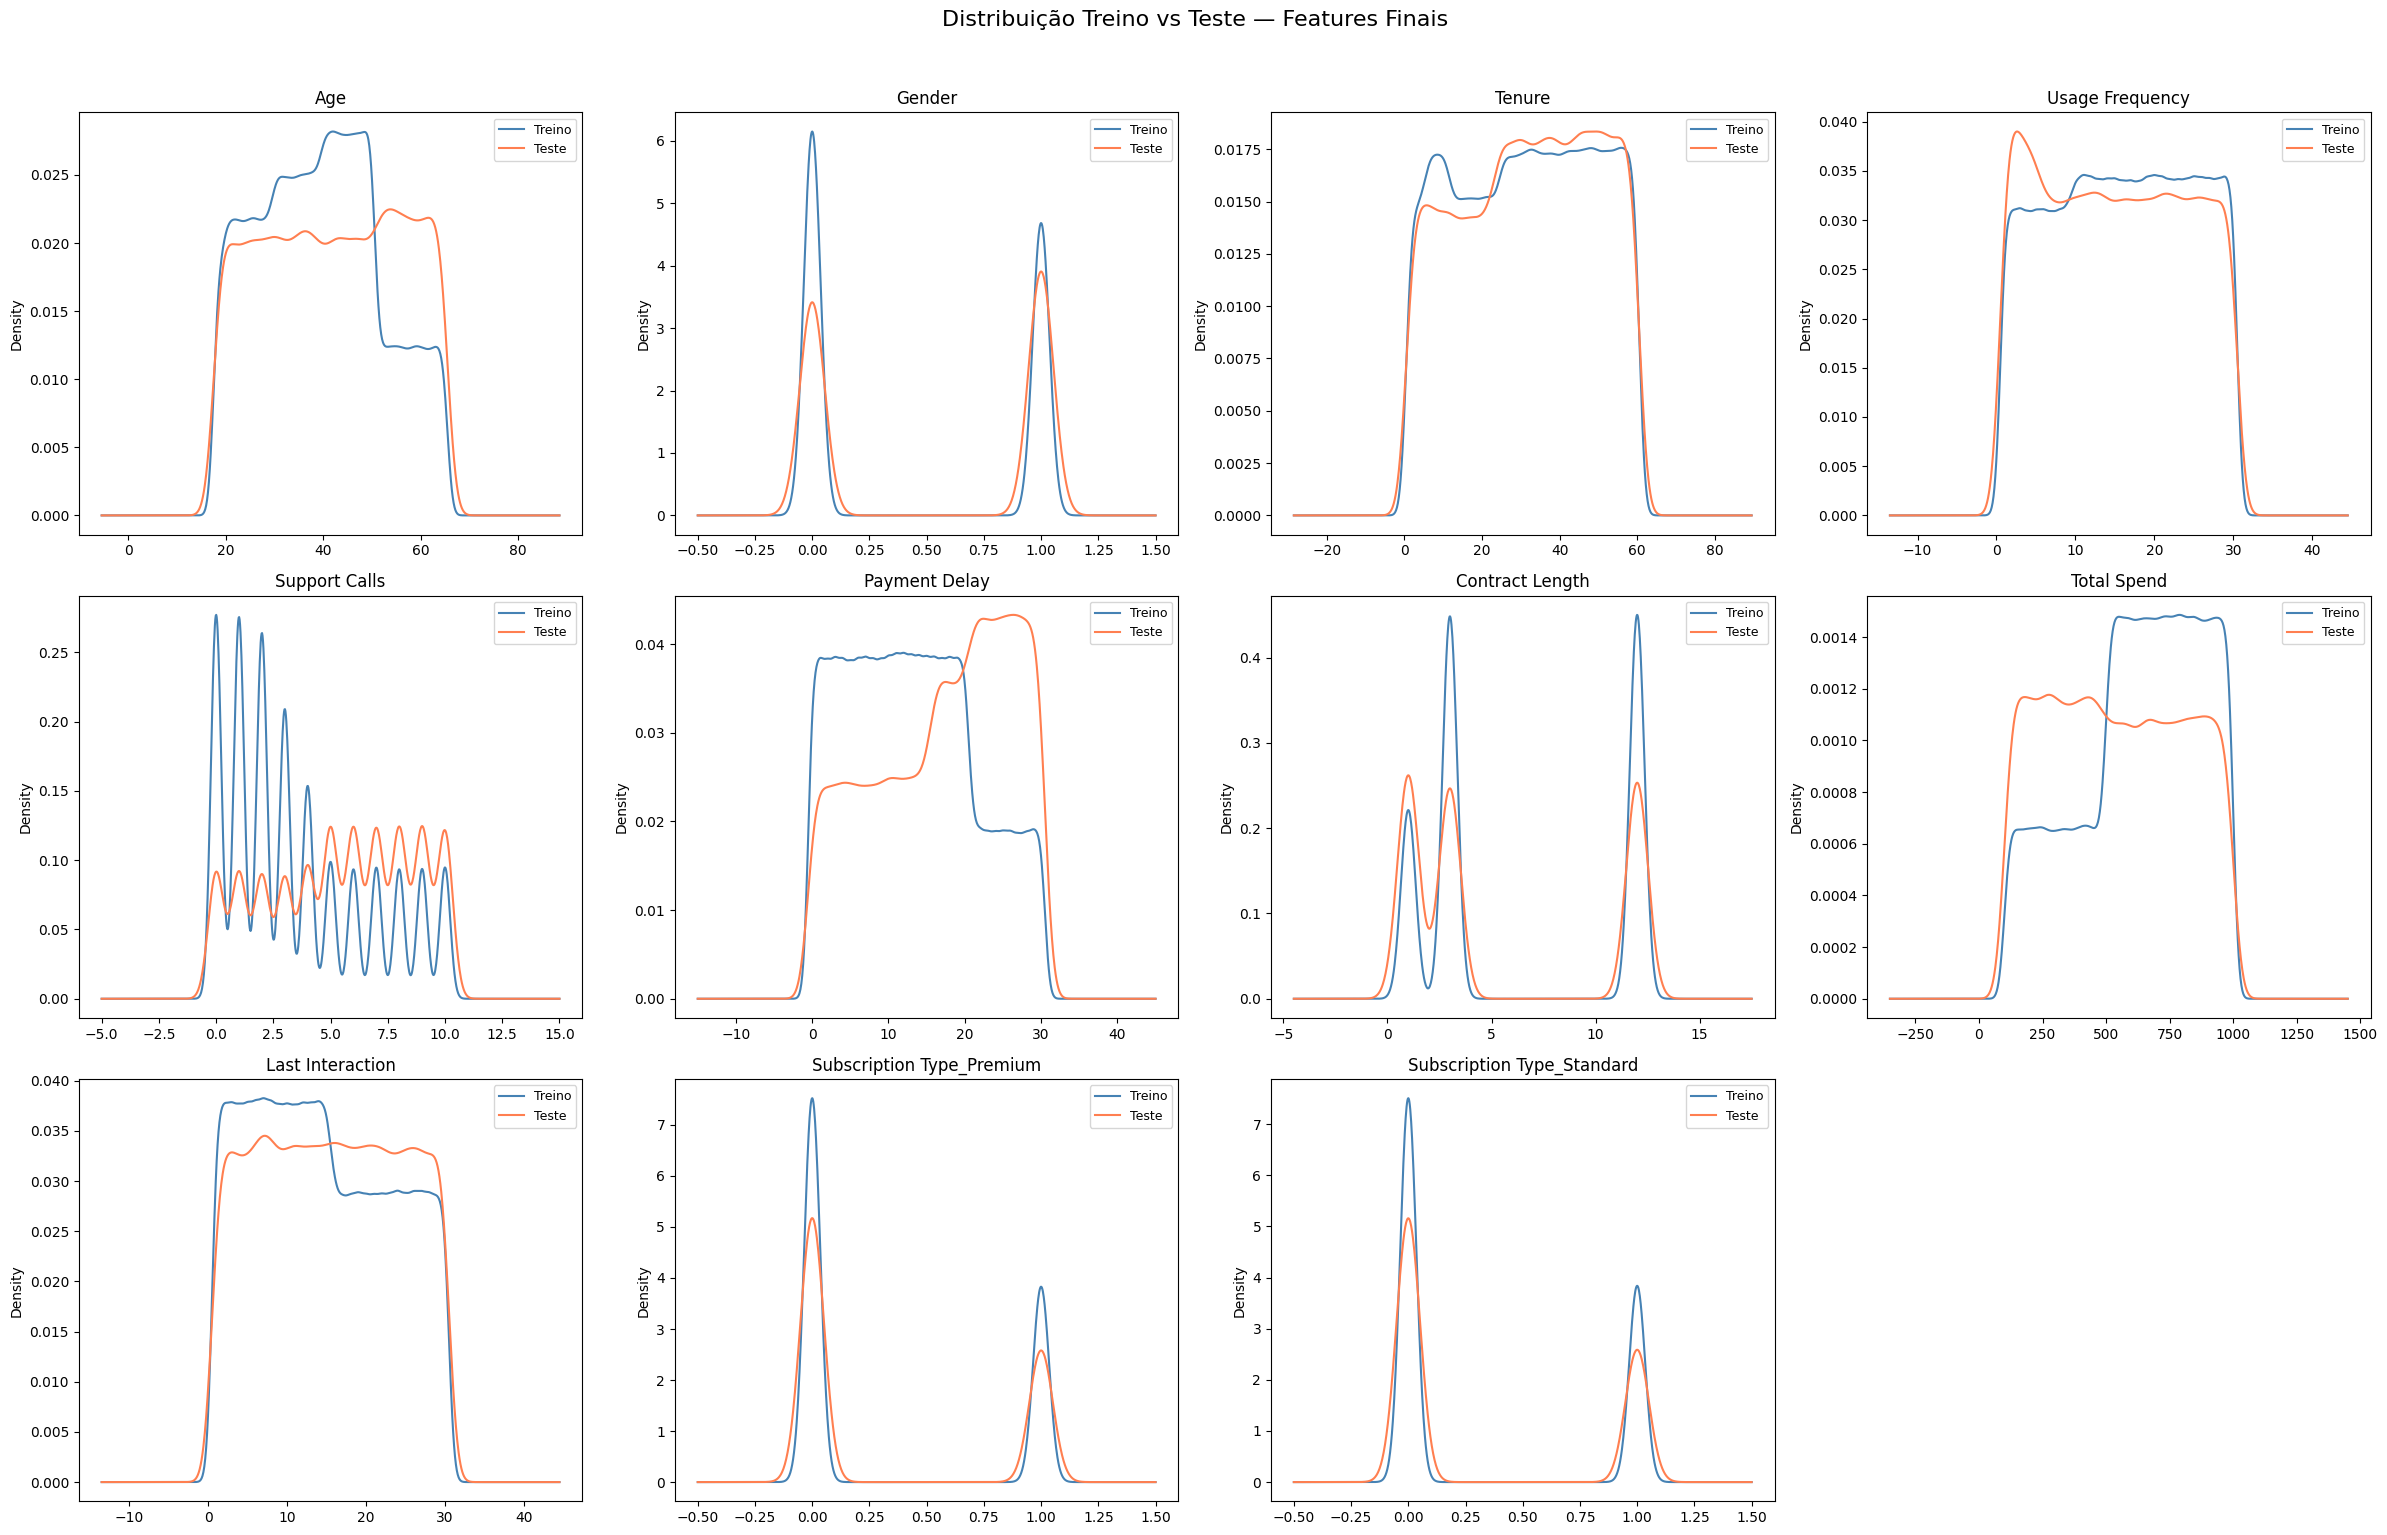

In [24]:
# KDE Treino vs Teste — features finais
cols_finais = [c for c in df_treino.columns if c != 'Churn']
n_cols = 4
n_rows = -(-len(cols_finais) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_finais):
    df_treino[col].plot.kde(ax=axes[i], color='steelblue', label='Treino')
    df_teste[col].plot.kde(ax=axes[i], color='coral', label='Teste')
    axes[i].set_title(col, fontsize=12)
    axes[i].legend(fontsize=9)

for j in range(len(cols_finais), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição Treino vs Teste — Features Finais', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_kde_features_finais.png', dpi=150, bbox_inches='tight')
plt.show()

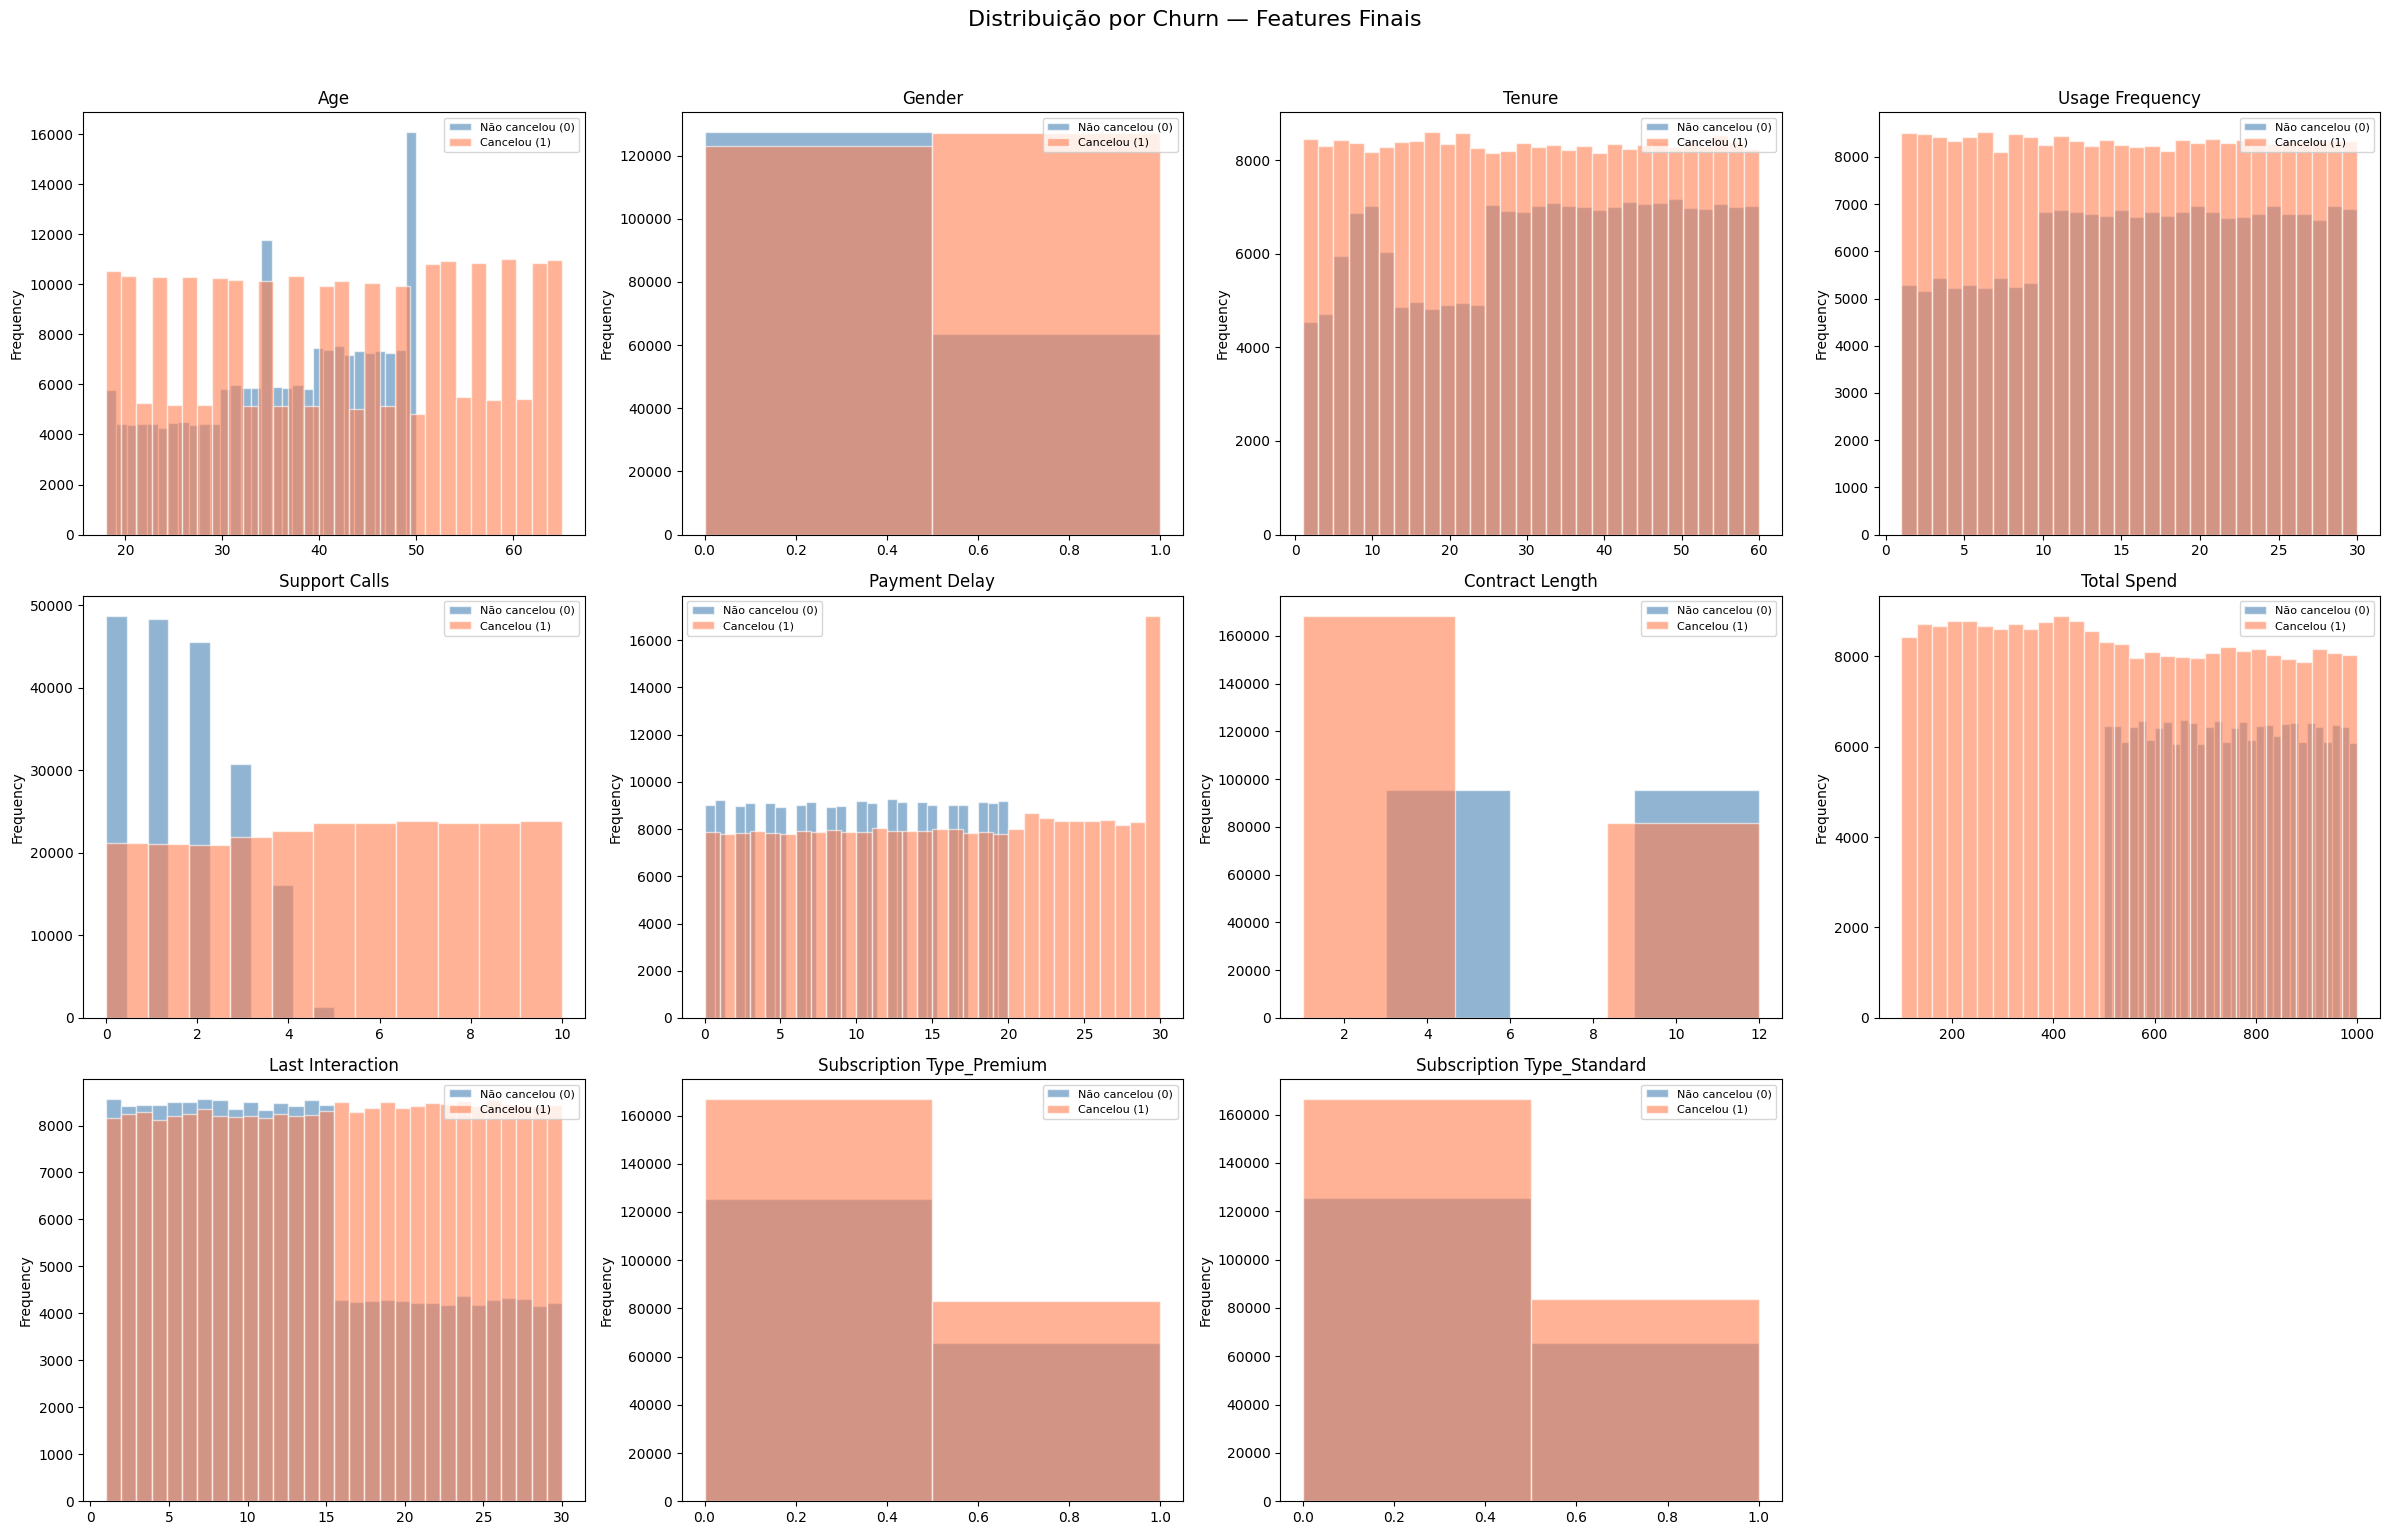

In [25]:
# Distribuição por Churn — features finais
n_cols = 4
n_rows = -(-len(cols_finais) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_finais):
    n_bins = min(df_treino[col].nunique(), 30)
    df_treino[df_treino['Churn'] == 0][col].plot.hist(
        ax=axes[i], bins=n_bins, alpha=0.6, color='steelblue', label='Não cancelou (0)', edgecolor='white'
    )
    df_treino[df_treino['Churn'] == 1][col].plot.hist(
        ax=axes[i], bins=n_bins, alpha=0.6, color='coral', label='Cancelou (1)', edgecolor='white'
    )
    axes[i].set_title(col, fontsize=12)
    axes[i].legend(fontsize=8)

for j in range(len(cols_finais), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição por Churn — Features Finais', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_churn_features_finais.png', dpi=150, bbox_inches='tight')
plt.show()

## Exportação dos Dados Processados

Exporta os DataFrames de treino e teste em formato **Parquet** para que os notebooks de modelagem (2A, 2B, 2C) possam importar os dados já preparados.

**Importante:**
- Os dados são exportados **já escalonados** com `StandardScaler` (fit no treino, transform no teste).
- Escalonamento não afeta modelos baseados em árvore (splits são invariantes a transformações monotônicas), então todos os notebooks usam os mesmos dados.
- Para regenerar os dados, basta re-executar este notebook inteiro.

In [26]:
import os
from datetime import datetime
from sklearn.preprocessing import StandardScaler

target = 'Churn'

X_train = df_treino.drop(columns=[target])
y_train = df_treino[[target]]
X_test = df_teste.drop(columns=[target])
y_test = df_teste[[target]]

# Escalonamento centralizado — fit no treino, transform no teste
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

output_dir = './dados_processados'
os.makedirs(output_dir, exist_ok=True)

X_train_scaled.to_parquet(f'{output_dir}/X_train.parquet', index=False)
y_train.to_parquet(f'{output_dir}/y_train.parquet', index=False)
X_test_scaled.to_parquet(f'{output_dir}/X_test.parquet', index=False)
y_test.to_parquet(f'{output_dir}/y_test.parquet', index=False)

print(f'Exportado em: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Diretório: {os.path.abspath(output_dir)}')
print(f'\nX_train: {X_train_scaled.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test_scaled.shape} | y_test:  {y_test.shape}')
print(f'\nFeatures: {list(X_train.columns)}')
print(f'Scaler: StandardScaler (fit no treino)')
print(f'\nVerificação (médias do treino escalado):')
print(X_train_scaled.mean().round(6).to_string())

Exportado em: 2026-06-24 15:43:38
Diretório: C:\Users\joaos\MEC\CMC13\Lab2\notebooks\dados_processados

X_train: (440832, 11) | y_train: (440832, 1)
X_test:  (64374, 11) | y_test:  (64374, 1)

Features: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Contract Length', 'Total Spend', 'Last Interaction', 'Subscription Type_Premium', 'Subscription Type_Standard']
Scaler: StandardScaler (fit no treino)

Verificação (médias do treino escalado):
Age                           0.0
Gender                        0.0
Tenure                        0.0
Usage Frequency              -0.0
Support Calls                 0.0
Payment Delay                 0.0
Contract Length               0.0
Total Spend                  -0.0
Last Interaction              0.0
Subscription Type_Premium     0.0
Subscription Type_Standard   -0.0
